# **Environment Setup, Library Imports, and Global Configuration**

In [1]:
# ==============================================================================
# ENVIRONMENT INSTALLATION
# Note: These are required for Google Colab environments.
# For local environments, see requirements.txt.
# ==============================================================================
!pip install shap optuna deepchem
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 552.4/552.4 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 74.0 MB/s eta 0:00:00


In [2]:
# ==============================================================================
# STEP 2: ALL IMPORTS & GLOBAL CONFIGURATION
# ==============================================================================

# Standard library
import os
import sys
import json
import random
import warnings
from pathlib import Path

# --- Data Science & Statistics ---
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors

# --- Deep Learning (PyTorch & Transformers) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup
from tqdm import tqdm

# --- Cheminformatics (RDKit & DeepChem) ---
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors

# --- Model Explainability (SHAP) ---
import shap
import shap.explainers._deep.deep_utils as deep_utils

# ==============================================================================
# STEP 3: GLOBAL CONFIGURATIONS
# ==============================================================================
# Increase SHAP tolerance for deep learning gradient internal checks
deep_utils.TOLERANCE = 100.0

# --- Hyperparameter Optimization (Optuna) ---
import optuna
from optuna.pruners import MedianPruner

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scipy
from scipy import stats
from scipy.stats import bootstrap

# Suppress warnings for cleaner GitHub/Notebook presentation
warnings.filterwarnings("ignore", category=UserWarning)

# ==============================================================================
# STEP 4: DEVICE ACCELERATION SETUP
# ==============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# **Data Loading and Initial Cleaning**

In [3]:
# ==============================================================================
# STEP 1: MOUNT GOOGLE DRIVE
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')


# ==============================================================================
# STEP 2: LOAD DATASET
# ==============================================================================
file_path = '/content/drive/MyDrive/LLM_six species/all_lambdaZHl_with_CAS_V2.csv'
# Read the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# ==============================================================================
# STEP 3: NUMERIC VALIDATION (DOSE)
# ==============================================================================
# Ensure 'Dose' is numeric; coerce errors (non-numeric strings) to NaN
df['Dose'] = pd.to_numeric(df['Dose'], errors='coerce')
df = df.dropna(subset=['Dose']).reset_index(drop=True)

df

Mounted at /content/drive


,Drug,Species,Route,Matrix,Dose,LambdaZHl,CitationNumber,SMILES
0,Oxytetracycline,Sheep,Intramuscular,Plasma,20.0,27.9600,8002009,CC1(C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C...
1,Oxytetracycline,Goats,Intramuscular,Plasma,20.0,28.0200,8002009,CC1(C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C...
2,Oxytetracycline,Swine,Intramuscular,Plasma,20.0,12.5867,8004003,CC1(C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C...
3,Oxytetracycline,Cattle,Intramuscular,Plasma,20.0,28.9000,8004004,CC1(C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C...
4,Oxytetracycline,Cattle,Intramuscular,Plasma,20.0,30.3000,8004004,CC1(C2C(C3C(C(=O)C(=C(C3(C(=O)C2=C(C4=C1C=CC=C...
...,...,...,...,...,...,...,...,...
4039,Enrofloxacin,Chickens,Oral,Plasma,20.0,6.6000,9019319,CCN1CCN(CC1)C2=C(C=C3C(=C2)N(C=C(C3=O)C(=O)O)C...
4040,Enrofloxacin,Chickens,Intravenous,Plasma,10.0,24.5000,9019319,CCN1CCN(CC1)C2=C(C=C3C(=C2)N(C=C(C3=O)C(=O)O)C...
4041,Enrofloxacin,Chickens,Intravenous,Plasma,10.0,5.2000,9019319,CCN1CCN(CC1)C2=C(C=C3C(=C2)N(C=C(C3=O)C(=O)O)C...
4042,Enrofloxacin,Chickens,Oral,Plasma,20.0,5.7000,9019319,CCN1CCN(CC1)C2=C(C=C3C(=C2)N(C=C(C3=O)C(=O)O)C...


In [4]:
# ==============================================================================
# STEP 4: DEDUPLICATION BASED ON FEATURE GROUPS
# ==============================================================================
# Identify all columns except the target 'LambdaZHl' to find unique feature sets

group_cols = [c for c in df.columns if c != 'LambdaZHl']

# Sort by LambdaZHl and drop duplicates, keeping the record with the highest LambdaZHl value for identical feature sets
df = (
    df
    .sort_values('LambdaZHl', ascending=False)
    .drop_duplicates(subset=group_cols, keep='first')
    .reset_index(drop=True)
)

# ==============================================================================
# STEP 5: REMOVING SAMPLES WITH MISSING CRITICAL FEATURES
# ==============================================================================
# Drop any rows where the target (LambdaZHl) or essential features are missing
df = df.dropna(subset=['LambdaZHl', 'SMILES', 'Route', 'Matrix'])

df

,Drug,Species,Route,Matrix,Dose,LambdaZHl,CitationNumber,SMILES
0,Tulathromycin,Sheep,Subcutaneous,Plasma,2.50,10196.000000,9018046,CCCNCC1(C(OC(CC1(C)OC)OC2C(C(C(CC(CNC(C(C(C(OC...
1,Fluazuron,Cattle,Subcutaneous,Kidney,1.50,7936.380000,9015577,C1=CC(=C(C(=C1)F)C(=O)NC(=O)NC2=CC(=C(C=C2)Cl)...
2,Fluazuron,Cattle,Subcutaneous,Plasma,1.50,1872.000000,9015577,C1=CC(=C(C(=C1)F)C(=O)NC(=O)NC2=CC(=C(C=C2)Cl)...
3,Fluazuron,Cattle,Subcutaneous,Plasma,1.00,1872.000000,9015168,C1=CC(=C(C(=C1)F)C(=O)NC(=O)NC2=CC(=C(C=C2)Cl)...
4,Sulfamethazine,Goats,Intramuscular,Kidney,100.00,1820.000000,9017889,CC1=CC(=NC(=N1)NS(=O)(=O)C2=CC=C(C=C2)N)C
...,...,...,...,...,...,...,...,...
2670,Thymoquinone,Chickens,Intravenous,Plasma,20.00,0.097800,9018340,CC1=CC(=O)C(=CC1=O)C(C)C
2671,T-2 toxin,Chickens,Intravenous,Plasma,0.02,0.065013,9016385,CC1=CC2C(CC1OC(=O)CC(C)C)(C3(C(C(C(C34CO4)O2)O...
2672,Reltecimod,Swine,Intravenous,Plasma,50.00,0.038333,9018763,CC(C)CC(C(=O)NC(C(C)C)C(=O)NC(C)C(=O)NC(CC1=CC...
2673,Reltecimod,Swine,Intravenous,Plasma,15.00,0.031667,9018763,CC(C)CC(C(=O)NC(C(C)C)C(=O)NC(C)C(=O)NC(CC1=CC...


In [5]:
# Step 6: Target and Dose Log Transformations
df['LambdaZHl'] = pd.to_numeric(df['LambdaZHl'], errors='coerce')

df['LambdaZHl_log'] = np.log(df['LambdaZHl'] + 1e-6)

# Log transform the dose, adding a small epsilon to avoid log(0)
df['Dose_log'] = np.log(df['Dose'] + 1e-9)

df

,Drug,Species,Route,Matrix,Dose,LambdaZHl,CitationNumber,SMILES,LambdaZHl_log,Dose_log
0,Tulathromycin,Sheep,Subcutaneous,Plasma,2.50,10196.000000,9018046,CCCNCC1(C(OC(CC1(C)OC)OC2C(C(C(CC(CNC(C(C(C(OC...,9.229751,9.162907e-01
1,Fluazuron,Cattle,Subcutaneous,Kidney,1.50,7936.380000,9015577,C1=CC(=C(C(=C1)F)C(=O)NC(=O)NC2=CC(=C(C=C2)Cl)...,8.979213,4.054651e-01
2,Fluazuron,Cattle,Subcutaneous,Plasma,1.50,1872.000000,9015577,C1=CC(=C(C(=C1)F)C(=O)NC(=O)NC2=CC(=C(C=C2)Cl)...,7.534763,4.054651e-01
3,Fluazuron,Cattle,Subcutaneous,Plasma,1.00,1872.000000,9015168,C1=CC(=C(C(=C1)F)C(=O)NC(=O)NC2=CC(=C(C=C2)Cl)...,7.534763,1.000000e-09
4,Sulfamethazine,Goats,Intramuscular,Kidney,100.00,1820.000000,9017889,CC1=CC(=NC(=N1)NS(=O)(=O)C2=CC=C(C=C2)N)C,7.506592,4.605170e+00
...,...,...,...,...,...,...,...,...,...,...
2670,Thymoquinone,Chickens,Intravenous,Plasma,20.00,0.097800,9018340,CC1=CC(=O)C(=CC1=O)C(C)C,-2.324820,2.995732e+00
2671,T-2 toxin,Chickens,Intravenous,Plasma,0.02,0.065013,9016385,CC1=CC2C(CC1OC(=O)CC(C)C)(C3(C(C(C(C34CO4)O2)O...,-2.733153,-3.912023e+00
2672,Reltecimod,Swine,Intravenous,Plasma,50.00,0.038333,9018763,CC(C)CC(C(=O)NC(C(C)C)C(=O)NC(C)C(=O)NC(CC1=CC...,-3.261409,3.912023e+00
2673,Reltecimod,Swine,Intravenous,Plasma,15.00,0.031667,9018763,CC(C)CC(C(=O)NC(C(C)C)C(=O)NC(C)C(=O)NC(CC1=CC...,-3.452459,2.708050e+00


# **SMILES Validation and Standardization**

In [6]:
# Validate and Clean SMILES structures
def validate_smiles(smiles_str):
    """Validate SMILES string and return cleaned version or None"""
    try:
        smiles_str = str(smiles_str).strip()
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            return None, f"Invalid SMILES structure"
        # Return canonical SMILES to standardize
        canonical_smiles = Chem.MolToSmiles(mol, isomericSmiles=True)
        return canonical_smiles, None
    except Exception as e:
        return None, str(e)

# Validate all SMILES
print("Validating SMILES structures...")
valid_smiles = []
invalid_indices = []
invalid_reasons = []

for idx, smiles in enumerate(tqdm(df['SMILES'], desc="Validating SMILES")):
    canonical, error = validate_smiles(smiles)
    if canonical is None:
        invalid_indices.append(idx)
        invalid_reasons.append(error)
        print(f"\nInvalid SMILES at index {idx}: {smiles}")
        print(f"  Reason: {error}")
    valid_smiles.append(canonical)

# Add validated SMILES back to dataframe
df['SMILES_validated'] = valid_smiles

# Report and remove invalid SMILES
if invalid_indices:
    print(f"\n{'='*80}")
    print(f"Found {len(invalid_indices)} invalid SMILES structures")

    # FIX: Use .iloc instead of .loc because invalid_indices are integer positions
    original_smiles_values = df['SMILES'].iloc[invalid_indices].values

    invalid_df = pd.DataFrame({
        'Index': invalid_indices,
        'Original_SMILES': original_smiles_values,
        'Reason': invalid_reasons
    })
    print(invalid_df)

    print(f"\nRemoving {len(invalid_indices)} rows with invalid SMILES...")
    df = df[df['SMILES_validated'].notna()].reset_index(drop=True)
    print(f"New shape: {df.shape}")
else:
    print("\nAll SMILES structures are valid!")

# Update SMILES column with validated data
df['SMILES'] = df['SMILES_validated']
df = df.drop('SMILES_validated', axis=1)

Validating SMILES structures...


Validating SMILES: 100%|██████████| 2671/2671 [00:01<00:00, 2232.08it/s]


All SMILES structures are valid!


# **Categorical Feature Encoding**

In [7]:
# Label Encoding for Species, Matrix, and Route
species_encoder = LabelEncoder()
matrix_encoder = LabelEncoder()
route_encoder = LabelEncoder()

df['species_id'] = species_encoder.fit_transform(df['Species'])
df['matrix_id'] = matrix_encoder.fit_transform(df['Matrix'])
df['route_id'] = route_encoder.fit_transform(df['Route'])

# Store species information for multi-task modeling
species_list = species_encoder.classes_
num_species = len(species_list)
print("Species being modeled as tasks:", species_list)

Species being modeled as tasks: ['Cattle' 'Chickens' 'Goats' 'Sheep' 'Swine' 'Turkeys']


# **Data Splitting and Feature Scaling**

In [8]:
# Three-Way Data Partitioning and Dose Standardization
# Split into (train + validation) and test sets
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=42)
# Further split (train + validation) into individual train and validation sets
train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42)

# Initialize and apply StandardScaler to the log-transformed dose
scaler = StandardScaler()
train_df['Dose_scaled'] = scaler.fit_transform(train_df[['Dose_log']])
val_df['Dose_scaled'] = scaler.transform(val_df[['Dose_log']])
test_df['Dose_scaled'] = scaler.transform(test_df[['Dose_log']])

# **Tokenizer Initialization and Configuration**

In [9]:
# Initialize Transformer Tokenizer with Stereochemical Support
# Load pre-trained ChemBERTa tokenizer
tokenizer = AutoTokenizer.from_pretrained("DeepChem/ChemBERTa-77M-MTR")

# Enhance tokenizer with special tokens for stereochemical awareness
tokenizer.add_special_tokens({'additional_special_tokens': ['/', '\\', '@']})  # Add stereo tokens

# Define maximum sequence length for drug SMILES strings
max_length = 256

tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/420 [00:00<?, ?B/s]

# **Stereochemical Feature Mapping**

In [10]:
# Define Stereochemical Token Mapping Function
def make_stereo_indices(input_ids, tokenizer):
    """Map token IDs '/', '\', '@' → 1, 2, 3; all else → 0."""
    slash_id     = tokenizer.convert_tokens_to_ids('/')
    backslash_id = tokenizer.convert_tokens_to_ids('\\')
    at_id        = tokenizer.convert_tokens_to_ids('@')

    # Ensure input is a 1D tensor for this logic
    if input_ids.dim() > 1:
        input_ids = input_ids.squeeze()

    si = torch.zeros_like(input_ids)
    si[input_ids == slash_id]     = 1
    si[input_ids == backslash_id] = 2
    si[input_ids == at_id]        = 3
    return si

# **Dataset Class and Model Architecture**

In [11]:
#Define the Hybrid Multi-Task Dataset and Transformer Model Architecture
class HybridMultiTaskDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.tokenizer   = tokenizer
        self.max_length  = max_length
        # Ensure clean data types for tensors
        self.smiles      = df['SMILES'].astype(str).values
        self.matrix_ids  = df['matrix_id'].astype(int).values
        self.route_ids   = df['route_id'].astype(int).values
        self.doses       = df['Dose_scaled'].astype(float).values
        self.species_ids = df['species_id'].astype(int).values
        self.labels      = df['LambdaZHl_log'].astype(float).values

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        inputs = self.tokenizer(
            self.smiles[idx],
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=self.max_length
        )
        return {
            'input_ids':      inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'matrix_id':      torch.tensor(self.matrix_ids[idx],  dtype=torch.long),
            'route_id':       torch.tensor(self.route_ids[idx],   dtype=torch.long),
            'dose':           torch.tensor(self.doses[idx],       dtype=torch.float32),
            'species_id':     torch.tensor(self.species_ids[idx], dtype=torch.long),
            'label':          torch.tensor(self.labels[idx],      dtype=torch.float32),
        }

class HybridMultiTaskModel(nn.Module):
    def __init__(self,
                 num_species, num_matrices, num_routes,
                 matrix_emb_dim, route_emb_dim, hidden_size, dropout_rate,
                 chemberta_name="DeepChem/ChemBERTa-77M-MTR",
                 tokenizer=None, stereo_emb_dim=8):
        super().__init__()
        # Load ChemBERTa base model
        self.chemberta = AutoModel.from_pretrained(chemberta_name)
        if tokenizer is not None:
            self.chemberta.resize_token_embeddings(len(tokenizer))
        # Metadata Embeddings
        self.matrix_embedding = nn.Embedding(num_matrices, matrix_emb_dim)
        self.route_embedding  = nn.Embedding(num_routes, route_emb_dim)

        # Stereochemical Token Embeddings (0: none, 1: '/', 2: '\', 3: '@')
        self.stereo_embedding = nn.Embedding(4, stereo_emb_dim)
        self.slash_id = self.backslash_id = self.at_id = None
        if tokenizer is not None:
            try:
                self.slash_id     = tokenizer.convert_tokens_to_ids('/')
                self.backslash_id = tokenizer.convert_tokens_to_ids('\\')
                self.at_id        = tokenizer.convert_tokens_to_ids('@')
            except Exception:
                pass
        # Calculate input size for the fully connected trunk
        combined_input_size = (self.chemberta.config.hidden_size
                               + matrix_emb_dim + route_emb_dim
                               + stereo_emb_dim + 1)
        # Shared trunk for multi-task learning
        self.shared_trunk = nn.Sequential(
            nn.Linear(combined_input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        # Final output layer mapping to species-specific tasks
        self.output_head = nn.Linear(hidden_size // 2, num_species)

    def _stereo_from_tokens(self, input_ids):
        # Generate stereo embedding by averaging token-level stereochemical tags
        idx = torch.zeros_like(input_ids)  # 0 = none
        if self.slash_id is not None:
            idx = torch.where(input_ids == self.slash_id,     torch.ones_like(idx), idx)
        if self.backslash_id is not None:
            idx = torch.where(input_ids == self.backslash_id, 2 * torch.ones_like(idx), idx)
        if self.at_id is not None:
            idx = torch.where(input_ids == self.at_id,        3 * torch.ones_like(idx), idx)
        stereo_tok = self.stereo_embedding(idx)                  # (B,L,stereo_emb_dim)
        return stereo_tok.mean(dim=1)                        # (B,stereo_emb_dim)

    def forward(self, input_ids, attention_mask, matrix_id, route_id, dose):
        out = self.chemberta(input_ids=input_ids, attention_mask=attention_mask)

        # Global Average Pooling if pooler_output is unavailable
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            chemberta_vec = out.pooler_output
        else:
            last = out.last_hidden_state
            mask = attention_mask.unsqueeze(-1).float()
            chemberta_vec = (last * mask).sum(1) / (mask.sum(1) + 1e-8)

        # Combine chemistry, metadata, stereo, and dose features
        matrix_emb = self.matrix_embedding(matrix_id)
        route_emb  = self.route_embedding(route_id)
        stereo_e   = self._stereo_from_tokens(input_ids)
        dose_vec   = dose.view(-1, 1).float()

        combined = torch.cat([chemberta_vec, matrix_emb, route_emb, stereo_e, dose_vec], dim=1)
        trunk = self.shared_trunk(combined)
        return self.output_head(trunk)

# **Model Evaluation and Performance Metrics**

In [12]:
# Define Evaluation Function for Species-Specific Performance
def evaluate_and_get_preds(model, data_loader, device, num_species):
    """Evaluates the model and returns species-level performance metrics and raw predictions."""
    model.eval()
    all_preds_per_species = [[] for _ in range(num_species)]
    all_labels_per_species = [[] for _ in range(num_species)]
    with torch.no_grad():
        for batch in data_loader:
            # Transfer batch data to computational device
            input_ids=batch['input_ids'].to(device)
            attention_mask=batch['attention_mask'].to(device)
            matrix_id=batch['matrix_id'].to(device)
            route_id=batch['route_id'].to(device)
            dose=batch['dose'].to(device)
            species_id=batch['species_id'].to(device)
            labels=batch['label'].to(device)
            # Forward pass through the Multi-Task model
            predictions = model(input_ids, attention_mask, matrix_id, route_id, dose)
            # Sort predictions and labels into their respective species tasks
            for i in range(num_species):
                mask = (species_id == i)
                if mask.any():
                  # Extract predictions specific to task 'i' for species 'i'
                    all_preds_per_species[i].extend(predictions[mask, i].cpu().numpy())
                    all_labels_per_species[i].extend(labels[mask].cpu().numpy())
    species_metrics = {}
    total_r2 = 0
    valid_species = 0

    # Calculate metrics (RMSE and R2) for each species individually
    for i, species_name in enumerate(species_list):
        if len(all_labels_per_species[i]) > 1:
            mse = mean_squared_error(all_labels_per_species[i], all_preds_per_species[i])
            r2 = r2_score(all_labels_per_species[i], all_preds_per_species[i])
            species_metrics[species_name] = {'RMSE': np.sqrt(mse), 'R2': r2}
            total_r2 += r2
            valid_species += 1
    avg_r2 = total_r2 / valid_species if valid_species > 0 else 0
    return avg_r2, species_metrics, all_preds_per_species, all_labels_per_species

# **SMILES Augmentation and Optuna Objective Function**

In [13]:
# Step 1: Define Data Augmentation and Hyperparameter Optimization Logic

# Utility to attempt RDKit import for SMILES randomization
try:
    from rdkit import Chem
except Exception:
    Chem = None

# Global Hyperparameter Tuning Constants
EPOCHS_PER_TRIAL = 40  # longer but with pruning
PATIENCE = 5  # early stopping patience
MODEL_NAME = "DeepChem/ChemBERTa-77M-MTR"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def _randomize_smiles_once(smi: str):
    if Chem is None:
        return None
    m = Chem.MolFromSmiles(str(smi))
    if m is None:
        return None
    return Chem.MolToSmiles(m, doRandom=True, canonical=False)

def _augment_df(df: pd.DataFrame, n_augment: int,
                mark_source: bool = True,
                dedupe: bool = False,
                shuffle: bool = True) -> pd.DataFrame:
    """
    Randomized-SMILES augmentation for TRAIN ONLY.
    - mark_source: adds 'Source' = {'experimental','simulated'}
    - dedupe: drop exact duplicate SMILES after augmentation
    - shuffle: shuffle rows after concat so augmented rows are mixed in
    """
    if n_augment <= 0 or Chem is None:
        out = df.copy()
        if mark_source and "Source" not in out.columns:
            out["Source"] = "experimental"
        return out

    base = df.copy()
    if mark_source:
        base["Source"] = "experimental"

    rows = []
    for _, row in base.iterrows():
        smi = str(row["SMILES"])
        m = Chem.MolFromSmiles(smi)
        if m is None:
            continue
        for _ in range(n_augment):
            # keep stereochemistry explicit
            new_smi = Chem.MolToSmiles(m, doRandom=True, canonical=False, isomericSmiles=True)
            new_row = row.copy()
            new_row["SMILES"] = new_smi
            if mark_source:
                new_row["Source"] = "simulated"
            rows.append(new_row)

    out = pd.concat([base, pd.DataFrame(rows)], ignore_index=True) if rows else base

    if dedupe:
        out = out.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)

    if shuffle:
        out = out.sample(frac=1.0, random_state=42).reset_index(drop=True)

    return out

def objective(trial):
    # 1) Define search space
    params = {
        # data
        "batch_size":   trial.suggest_categorical("batch_size", [16, 32, 64]),
        "n_augment":    trial.suggest_categorical("n_augment", [0, 1, 5, 10, 20, 50]),

        # model
        "dropout_rate": trial.suggest_float("dropout_rate", 0.20, 0.55),
        "matrix_emb_dim": trial.suggest_categorical("matrix_emb_dim", [8, 16, 32]),
        "route_emb_dim":  trial.suggest_categorical("route_emb_dim",  [4, 8, 16]),
        "hidden_size":    trial.suggest_categorical("hidden_size",    [256, 512, 1024]),

        # optim
        "bert_lr":      trial.suggest_float("bert_lr", 1.5e-5, 6e-5, log=True),
        "head_lr":      trial.suggest_float("head_lr", 1e-4,   7e-4, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-7, 5e-5, log=True),
        "epochs":       EPOCHS_PER_TRIAL,
        "warmup_ratio": 0.10,
    }

    # 2) Cross-validation split and augmentation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    idx_tr, idx_va = next(kf.split(train_df))
    train_sub = train_df.iloc[idx_tr].copy()
    val_sub   = train_df.iloc[idx_va].copy()

    # 3) Dataloaders
    train_aug = _augment_df(train_sub, params["n_augment"], mark_source=True, dedupe=False, shuffle=True)

    out_path = f"/content/drive/MyDrive/all_multi/augmented_trial{trial.number}.csv"
    train_aug.to_csv(out_path, index=False)

    train_dataset = HybridMultiTaskDataset(train_aug, tokenizer)
    val_dataset   = HybridMultiTaskDataset(val_sub,  tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=params["batch_size"])

    # 4) Model setup
    model = HybridMultiTaskModel(
        num_species,                           # logits per species
        len(matrix_encoder.classes_),
        len(route_encoder.classes_),
        params["matrix_emb_dim"],
        params["route_emb_dim"],
        params["hidden_size"],
        params["dropout_rate"],
        chemberta_name=MODEL_NAME,
        tokenizer=tokenizer,              # <-- pass tokenizer here
    ).to(device)

    # 5) Multi-tier optimization
    head_params = list(model.matrix_embedding.parameters()) + \
                  list(model.route_embedding.parameters()) + \
                  list(model.shared_trunk.parameters()) + \
                  list(model.output_head.parameters()) + \
                  list(model.stereo_embedding.parameters())

    optimizer = AdamW([
        {"params": model.chemberta.parameters(), "lr": params["bert_lr"]},
        {"params": head_params,                  "lr": params["head_lr"]},
    ], weight_decay=params["weight_decay"])

    total_steps = max(1, len(train_loader) * params["epochs"])
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(params["warmup_ratio"] * total_steps),
        num_training_steps=total_steps
    )

    # Huber is a bit more robust than pure MSE for noisy labels
    criterion = nn.HuberLoss()

    # 6) Training loop with early stopping and pruning
    best_r2 = -np.inf
    patience_counter = 0
    best_model_state = None

    for epoch in range(params["epochs"]):
        model.train()
        train_loss = 0.0
        n_batches = 0

        for batch in train_loader:
            optimizer.zero_grad()

            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            matrix_id      = batch["matrix_id"].to(device)
            route_id       = batch["route_id"].to(device)
            dose           = batch["dose"].to(device).float()
            species_id     = batch["species_id"].to(device)
            labels         = batch["label"].to(device).float()

            # Forward
            preds_all = model(input_ids, attention_mask, matrix_id, route_id, dose)

            # Handle both multi-head and single-head models gracefully:
            # - If preds_all shape == [B, num_species]: gather by species
            # - If preds_all shape == [B, 1] or [B]:     use directly
            if preds_all.dim() == 2 and preds_all.size(1) == num_species:
                preds = preds_all.gather(1, species_id.view(-1, 1)).squeeze(1)
            else:
                preds = preds_all.view(-1)

            loss = criterion(preds, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            n_batches += 1

        avg_train_loss = train_loss / n_batches if n_batches > 0 else 0.0

        # =============== Validation Phase ===============
        avg_r2, _, _, _ = evaluate_and_get_preds(model, val_loader, device, num_species)

        # Report to Optuna for pruning
        trial.report(avg_r2, step=epoch)
        if trial.should_prune():
            print(f"Trial {trial.number} pruned by Optuna at epoch {epoch+1}")
            raise optuna.exceptions.TrialPruned()

        # =============== Early Stopping Logic ===============
        if avg_r2 > best_r2:
            best_r2 = avg_r2
            patience_counter = 0
            # Save best model state in memory
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            print(f"Trial {trial.number}, Epoch {epoch+1}/{params['epochs']}: "
                  f"Train Loss={avg_train_loss:.4f}, Val R²={avg_r2:.4f} ✓ NEW BEST")
        else:
            patience_counter += 1
            print(f"Trial {trial.number}, Epoch {epoch+1}/{params['epochs']}: "
                  f"Train Loss={avg_train_loss:.4f}, Val R²={avg_r2:.4f} "
                  f"(No improvement: {patience_counter}/{PATIENCE})")

        # Check early stopping condition
        if patience_counter >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch+1} for trial {trial.number}")
            print(f"Best Val R² for this trial: {best_r2:.4f}")
            break

    # =============== Save best model for this trial ===============
    if best_model_state is not None:
        # Load best model state back to model
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
        # Save to disk
        best_model_path = f"/content/drive/MyDrive/all_multi/trial{trial.number}_best_model.pt"
        torch.save(best_model_state, best_model_path)
        print(f"Best model for trial {trial.number} saved to {best_model_path}")

    # Clean up GPU memory
    del model
    torch.cuda.empty_cache()

    return best_r2

# **Data Distribution and Encoding Verification**

In [14]:
print("Species present in dataset:")
print(df['Species'].value_counts())
print("\nEncoded species_list:")
print(species_list)

Species present in dataset:
Species
Cattle      752
Swine       606
Sheep       520
Chickens    432
Goats       266
Turkeys      95
Name: count, dtype: int64

Encoded species_list:
['Cattle' 'Chickens' 'Goats' 'Sheep' 'Swine' 'Turkeys']


# **Hyperparameter Optimization Execution**

In [15]:
#Initialize and run the Optuna study to find optimal hyperparameters
study = optuna.create_study(direction="maximize", pruner=MedianPruner(n_warmup_steps=5))

# Execute the optimization for 100 trials
study.optimize(objective, n_trials=100)

# Display final tuning results
print("Tuning done.")
print("Best trial:", study.best_trial.params)
print("Best value:", study.best_trial.value)
print("Best number:", study.best_trial.number)
print("Best params:", study.best_trial.params)

[I 2026-01-09 05:23:04,516] A new study created in memory with name: no-name-d1c4c6e2-0444-4cf9-8f55-e7b7015b0a3b


pytorch_model.bin:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Trial 0, Epoch 1/40: Train Loss=2.4554, Val R²=-2.5541 ✓ NEW BEST
Trial 0, Epoch 2/40: Train Loss=1.9407, Val R²=-0.4985 ✓ NEW BEST
Trial 0, Epoch 3/40: Train Loss=0.9927, Val R²=0.2469 ✓ NEW BEST
Trial 0, Epoch 4/40: Train Loss=0.7144, Val R²=0.3880 ✓ NEW BEST
Trial 0, Epoch 5/40: Train Loss=0.6300, Val R²=0.4129 ✓ NEW BEST
Trial 0, Epoch 6/40: Train Loss=0.6012, Val R²=0.4656 ✓ NEW BEST
Trial 0, Epoch 7/40: Train Loss=0.5825, Val R²=0.4674 ✓ NEW BEST
Trial 0, Epoch 8/40: Train Loss=0.5538, Val R²=0.4563 (No improvement: 1/5)
Trial 0, Epoch 9/40: Train Loss=0.5361, Val R²=0.4599 (No improvement: 2/5)
Trial 0, Epoch 10/40: Train Loss=0.5140, Val R²=0.4760 ✓ NEW BEST
Trial 0, Epoch 11/40: Train Loss=0.5069, Val R²=0.4789 ✓ NEW BEST
Trial 0, Epoch 12/40: Train Loss=0.4967, Val R²=0.4813 ✓ NEW BEST
Trial 0, Epoch 13/40: Train Loss=0.4807, Val R²=0.4978 ✓ NEW BEST
Trial 0, Epoch 14/40: Train Loss=0.4753, Val R²=0.4735 (No improvement: 1/5)
Trial 0, Epoch 15/40: Train Loss=0.4700, Val R²=0.

...

Trial 98 pruned by Optuna at epoch 6


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trial 99, Epoch 1/40: Train Loss=2.1588, Val R²=-0.3556 ✓ NEW BEST
Trial 99, Epoch 2/40: Train Loss=0.7954, Val R²=0.3500 ✓ NEW BEST
Trial 99, Epoch 3/40: Train Loss=0.6000, Val R²=0.4207 ✓ NEW BEST
Trial 99, Epoch 4/40: Train Loss=0.5438, Val R²=0.4604 ✓ NEW BEST
Trial 99, Epoch 5/40: Train Loss=0.4891, Val R²=0.4915 ✓ NEW BEST


[I 2026-01-09 14:19:39,177] Trial 99 pruned. 


Trial 99 pruned by Optuna at epoch 6
Tuning done.
Best trial: {'batch_size': 32, 'n_augment': 20, 'dropout_rate': 0.3783247181404379, 'matrix_emb_dim': 8, 'route_emb_dim': 16, 'hidden_size': 256, 'bert_lr': 1.5332017448068264e-05, 'head_lr': 0.000695739425121773, 'weight_decay': 5.2156960308286745e-06}
Best value: 0.6203711539299163
Best number: 11
Best params: {'batch_size': 32, 'n_augment': 20, 'dropout_rate': 0.3783247181404379, 'matrix_emb_dim': 8, 'route_emb_dim': 16, 'hidden_size': 256, 'bert_lr': 1.5332017448068264e-05, 'head_lr': 0.000695739425121773, 'weight_decay': 5.2156960308286745e-06}


In [16]:
best_config = study.best_trial.params

# **Final Model Configuration**

In [17]:
# Extract optimal hyperparameters from the Optuna study

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_config   = study.best_trial.params
BATCH_SIZE     = best_config.get("batch_size", 32)
N_AUGMENT      = best_config.get("n_augment", 0)
DROPOUT_RATE   = best_config.get("dropout_rate", 0.3)
HIDDEN_SIZE    = best_config.get("hidden_size", 512)
MATRIX_EMB_DIM = best_config.get("matrix_emb_dim", 16)
ROUTE_EMB_DIM  = best_config.get("route_emb_dim", 8)
BERT_LR        = best_config.get("bert_lr", 3e-5)
HEAD_LR        = best_config.get("head_lr", 3e-4)
WEIGHT_DECAY   = best_config.get("weight_decay", 1e-6)
EPOCHS         = best_config.get("epochs", best_config.get("epochs_total", 40))
WARMUP_RATIO   = 0.10
MODEL_NAME     = "DeepChem/ChemBERTa-77M-MTR"
RANDOM_SEED    = best_config.get("random_seed", 42)

# **Final Model Training and Evaluation**

In [18]:
# Step 1: Initialize Tokenizer and Alignment
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_special_tokens({'additional_special_tokens': ['/', '\\', '@']})

# Step 2: Align Dataframe Columns for the Dataset Class
def align_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "Route_enc" in out and "route_id" not in out:     out["route_id"] = out["Route_enc"]
    if "Matrix_enc" in out and "matrix_id" not in out:   out["matrix_id"] = out["Matrix_enc"]
    if "Species_enc" in out and "species_id" not in out: out["species_id"] = out["Species_enc"]

    # Target Label alignment
    if "LambdaZHl_log" not in out:
        if "LambdaZHl_scaled" in out:
            out["LambdaZHl_log"] = out["LambdaZHl_scaled"]
        elif "label" in out:
            out["LambdaZHl_log"] = out["label"]
        else:
            raise ValueError("Need a label column: LambdaZHl_log / LambdaZHl_scaled / label.")

    # Dose column alignment
    if "Dose_scaled" not in out:
        if "Dose_log" in out: out["Dose_scaled"] = out["Dose_log"]
        elif "Dose" in out:   out["Dose_scaled"] = out["Dose"]
        else: raise ValueError("Need dose column: Dose_scaled / Dose_log / Dose.")
    return out

train_df_al = align_cols(train_df)
val_df_al   = align_cols(val_df)
test_df_al  = align_cols(test_df)

# Step 3: Training Set Augmentation
try:
    from rdkit import Chem
except Exception:
    Chem = None

def augment_df(df: pd.DataFrame, n_aug: int) -> pd.DataFrame:
    if n_aug <= 0 or Chem is None:
        return df.copy()
    rows = []
    for _, row in df.iterrows():
        m = Chem.MolFromSmiles(str(row["SMILES"]))
        if m is None: continue
        for _ in range(n_aug):
            new_row = row.copy()
            new_row["SMILES"] = Chem.MolToSmiles(m, doRandom=True, canonical=False)
            rows.append(new_row)
    return pd.concat([df, pd.DataFrame(rows)], ignore_index=True) if rows else df.copy()

train_df_final = augment_df(train_df_al, N_AUGMENT)

# Step 4: Reproducibility Seeding
torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); random.seed(RANDOM_SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(RANDOM_SEED)

# Step 5: DataLoaders Initialization
train_dataset = HybridMultiTaskDataset(train_df_final, tokenizer, max_length=128)
val_dataset   = HybridMultiTaskDataset(val_df_al,     tokenizer, max_length=128)
test_dataset  = HybridMultiTaskDataset(test_df_al,    tokenizer, max_length=128)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

# Step 6: Model and Optimizer Construction
num_species = int(max(train_df_al["species_id"].max(), val_df_al["species_id"].max(), test_df_al["species_id"].max()) + 1)
model = HybridMultiTaskModel(
    num_species=num_species,
    num_matrices=int(train_df_al["matrix_id"].max()+1),
    num_routes=int(train_df_al["route_id"].max()+1),
    matrix_emb_dim=MATRIX_EMB_DIM,
    route_emb_dim=ROUTE_EMB_DIM,
    hidden_size=HIDDEN_SIZE,
    dropout_rate=DROPOUT_RATE,
    chemberta_name=MODEL_NAME,
    tokenizer=tokenizer
).to(device)

# Differential learning rates for backbone and custom heads
head_params = list(model.matrix_embedding.parameters()) + \
              list(model.route_embedding.parameters()) + \
              list(model.shared_trunk.parameters()) + \
              list(model.output_head.parameters()) + \
              list(model.stereo_embedding.parameters())

optimizer = AdamW([
    {"params": model.chemberta.parameters(), "lr": BERT_LR},
    {"params": head_params,                  "lr": HEAD_LR},
], weight_decay=WEIGHT_DECAY)

total_steps = max(1, len(train_loader) * EPOCHS)
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)
criterion = nn.HuberLoss()

# Step 7: Training and Evaluation Loops
def train_one_epoch():
    model.train()
    total = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        ids  = batch["input_ids"].to(device)
        msk  = batch["attention_mask"].to(device)
        mx   = batch["matrix_id"].to(device)
        rt   = batch["route_id"].to(device)
        dose = batch["dose"].to(device).float()
        sp   = batch["species_id"].to(device)
        y    = batch["label"].to(device).float()

        logits = model(ids, msk, mx, rt, dose)              # [B, num_species]
        pred   = logits.gather(1, sp.view(-1,1)).squeeze(1) # gather true species
        loss   = criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total += loss.item()
    return total / max(1, len(train_loader))

@torch.no_grad()
def eval_split(loader):
    model.eval()
    y_true, y_pred, sp_idx = [], [], []
    for batch in loader:
        ids, msk, mx, rt = batch["input_ids"].to(device), batch["attention_mask"].to(device), batch["matrix_id"].to(device), batch["route_id"].to(device)
        dose, sp, y = batch["dose"].to(device).float(), batch["species_id"].to(device), batch["label"].to(device).float()

        logits = model(ids, msk, mx, rt, dose)
        pred = logits.gather(1, sp.view(-1, 1)).squeeze(1)

        y_true.append(y.cpu().numpy()); y_pred.append(pred.cpu().numpy()); sp_idx.append(sp.cpu().numpy())

    y_true, y_pred, sp_idx = np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(sp_idx)
    from sklearn.metrics import r2_score
    overall_r2 = float(r2_score(y_true, y_pred))

    try: species_list = list(species_encoder.classes_)
    except Exception: species_list = [f"Species_{i}" for i in range(int(sp_idx.max()) + 1)]

    test_labels, test_preds, test_metrics = [], [], {}
    for i in sorted(np.unique(sp_idx).tolist()):
        mask = (sp_idx == i)
        yi, pi = y_true[mask], y_pred[mask]
        name = species_list[i] if i < len(species_list) else f"Species_{i}"
        r2i = float(r2_score(yi, pi)) if yi.size > 1 else float("nan")
        test_metrics[name] = {"R2": r2i, "n": int(yi.size)}
        test_labels.append(yi.tolist()); test_preds.append(pi.tolist())

    return overall_r2, species_list, test_labels, test_preds, test_metrics

# Step 8: Final Training Execution
print("Training best-config model...")
best_val_r2 = -1e9
for ep in range(1, EPOCHS+1):
    tr_loss = train_one_epoch()
    val_r2, *_ = eval_split(val_loader)
    print(f"Epoch {ep:02d}/{EPOCHS} | Train {tr_loss:.4f} | Val R² {val_r2:.4f}")
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        torch.save(model.state_dict(), "best_single_model.pt")

# Final Evaluation on Held-out Test Set
model.load_state_dict(torch.load("best_single_model.pt", map_location=device))
test_r2, species_list, test_labels, test_preds, test_metrics = eval_split(test_loader)
print(f"\nFINAL Test R² (overall): {test_r2:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-77M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training best-config model...
Epoch 01/40 | Train 1.2510 | Val R² 0.5815
Epoch 02/40 | Train 0.5515 | Val R² 0.6309
Epoch 03/40 | Train 0.4581 | Val R² 0.6663
Epoch 04/40 | Train 0.3942 | Val R² 0.6407
Epoch 05/40 | Train 0.3519 | Val R² 0.6725
Epoch 06/40 | Train 0.3209 | Val R² 0.6975
Epoch 07/40 | Train 0.2964 | Val R² 0.6869
Epoch 08/40 | Train 0.2828 | Val R² 0.6846
Epoch 09/40 | Train 0.2670 | Val R² 0.6874
Epoch 10/40 | Train 0.2539 | Val R² 0.6891
Epoch 11/40 | Train 0.2451 | Val R² 0.6901
Epoch 12/40 | Train 0.2385 | Val R² 0.6965
Epoch 13/40 | Train 0.2290 | Val R² 0.6775
Epoch 14/40 | Train 0.2238 | Val R² 0.6800
Epoch 15/40 | Train 0.2176 | Val R² 0.6917
Epoch 16/40 | Train 0.2112 | Val R² 0.6863
Epoch 17/40 | Train 0.2070 | Val R² 0.6856
Epoch 18/40 | Train 0.2011 | Val R² 0.6814
Epoch 19/40 | Train 0.1983 | Val R² 0.6801
Epoch 20/40 | Train 0.1953 | Val R² 0.6823
Epoch 21/40 | Train 0.1897 | Val R² 0.6836
Epoch 22/40 | Train 0.1876 | Val R² 0.6841
Epoch 23/40 | Train 0.18

# **Results Visualization**


----- Generating Plots for Test Set Results -----


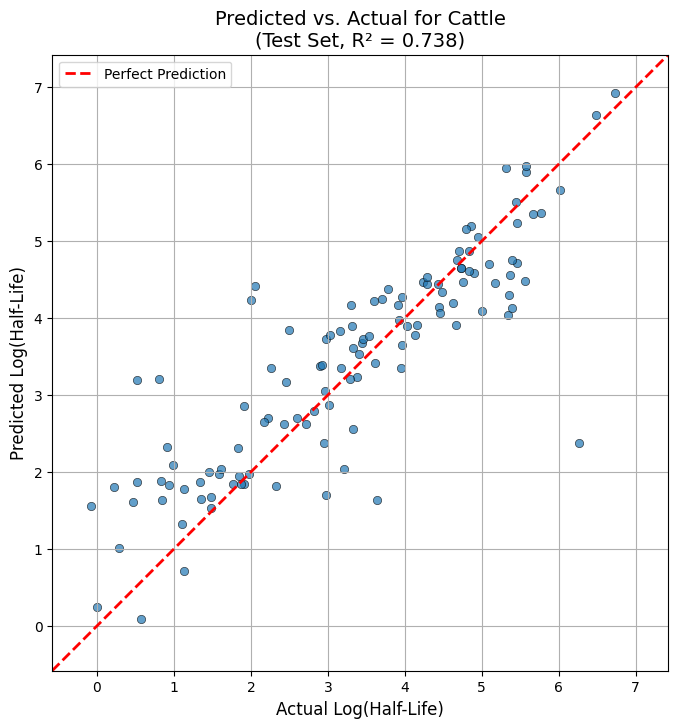

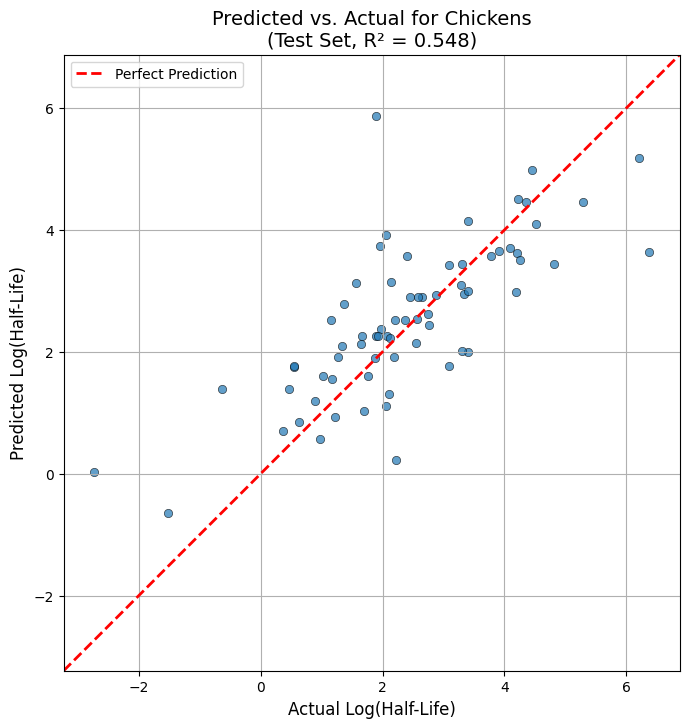

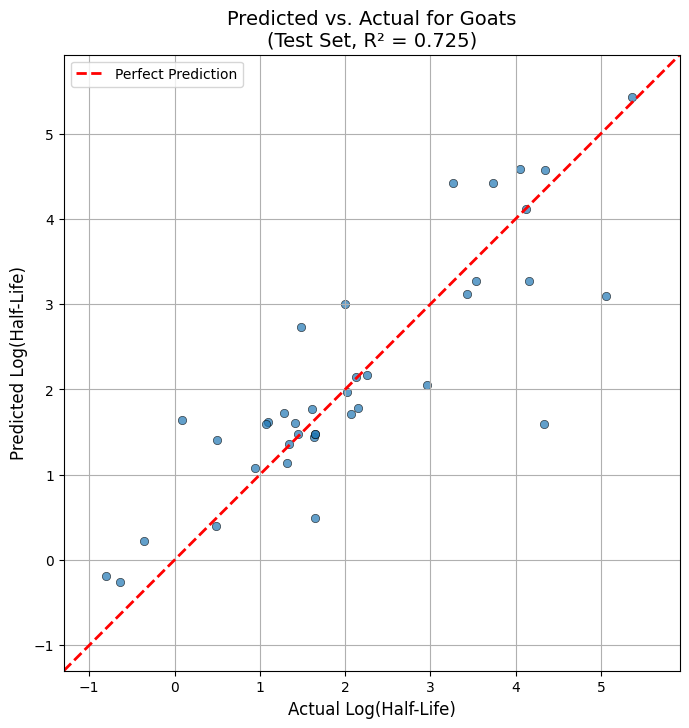

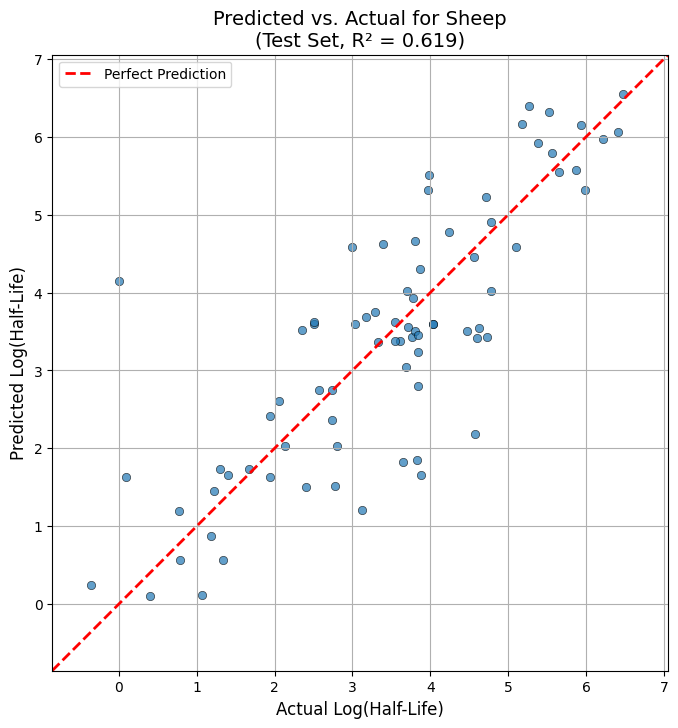

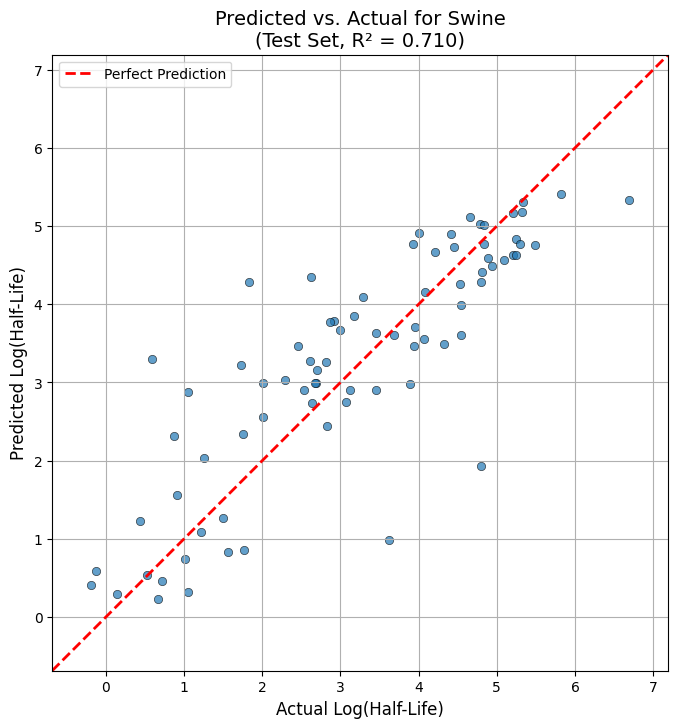

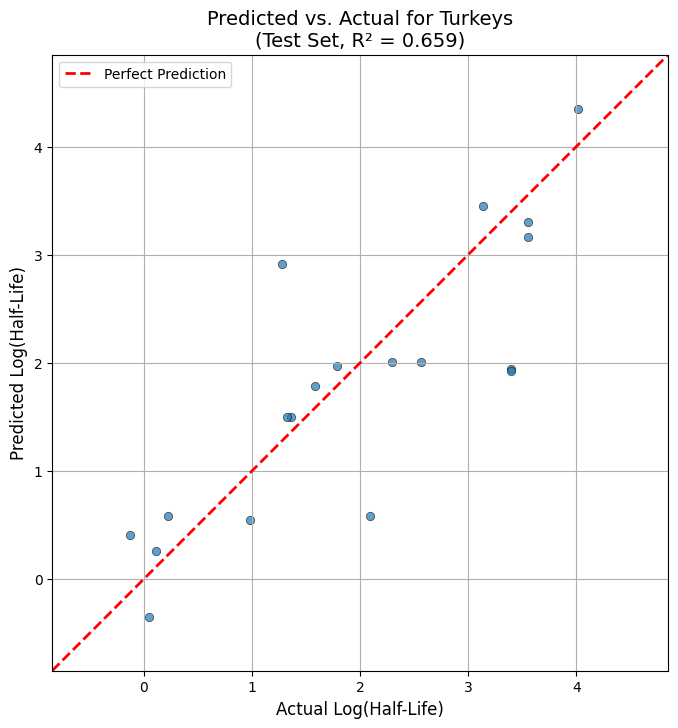

In [19]:
# Step 1: Generate Predicted vs. Actual Scatter Plots for the Test Set
print("\n----- Generating Plots for Test Set Results -----")
for i, species_name in enumerate(species_list):
  # Retrieve data from the evaluation results
    actuals = test_labels[i]
    preds = test_preds[i]

    if len(actuals) > 0:
      # Fetch R² metric for the title
        r2 = test_metrics[species_name]['R2']

        plt.figure(figsize=(8, 8))
        plt.scatter(actuals, preds, alpha=0.7, edgecolors='k', linewidth=0.5)
        min_val = min(min(actuals), min(preds)) - 0.5
        max_val = max(max(actuals), max(preds)) + 0.5
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        plt.xlabel("Actual Log(Half-Life)", fontsize=12)
        plt.ylabel("Predicted Log(Half-Life)", fontsize=12)
        plt.title(f"Predicted vs. Actual for {species_name}\n(Test Set, R\u00b2 = {r2:.3f})", fontsize=14)
        plt.legend()
        plt.grid(True)
        plt.gca().set_aspect('equal', adjustable='box')
        plt.xlim(min_val, max_val)
        plt.ylim(min_val, max_val)
        plt.show()

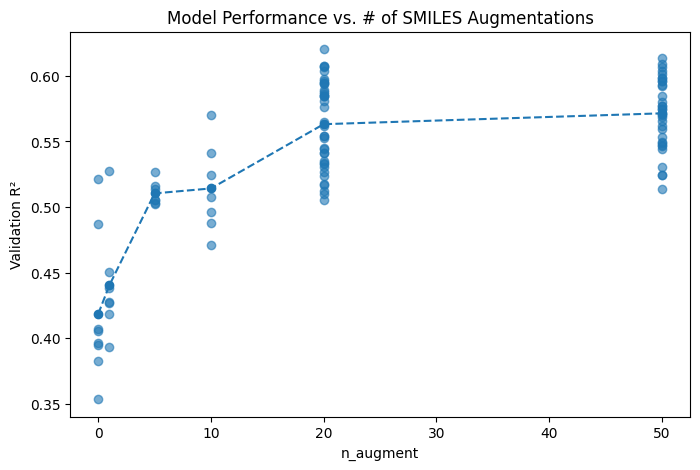

In [20]:
# collect (n_augment, best_r2) for each finished trial
aug_vs_r2 = [(t.params['n_augment'], t.value)
             for t in study.trials if t.value is not None]

x_vals, y_vals = zip(*aug_vs_r2)

plt.figure(figsize=(8,5))
plt.scatter(x_vals, y_vals, alpha=0.6)
plt.xlabel("n_augment")
plt.ylabel("Validation R²")
plt.title("Model Performance vs. # of SMILES Augmentations")

# plot mean R² for each augmentation level
levels = sorted(set(x_vals))
mean_r2 = [np.mean([r2 for aug, r2 in aug_vs_r2 if aug == lvl])
           for lvl in levels]
plt.plot(levels, mean_r2, marker='o', linestyle='--')
plt.show()

AD leverage threshold h*: 0.0101
AD kNN 95% radius t_knn: 0.7508
Train in-domain: 95.0% | Test in-domain: 83.3%


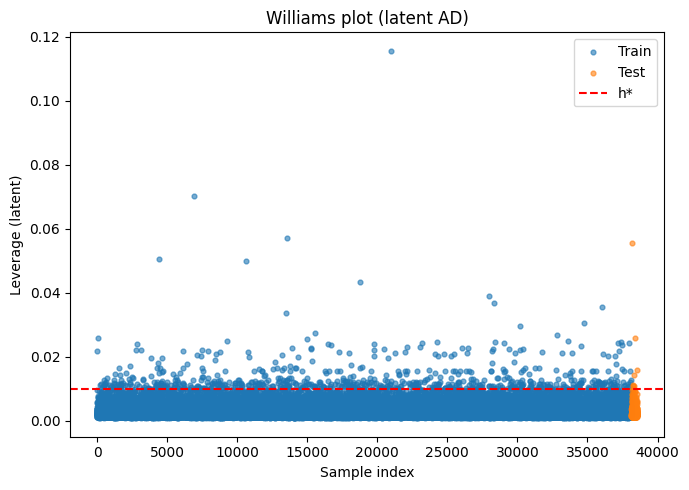

In [21]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# --- helpers to match the model's feature building ---
def masked_mean(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).float()
    return (last_hidden_state * mask).sum(1) / (mask.sum(1) + 1e-8)

def build_stereo_embedding(ids, batch, model, tokenizer, device):
    """
    Returns stereo_e (B, E_st) or None if the model has no stereo embedding.
    Supports:
      - token-level: model.stereo_embed (4 classes over tokens '/', '\\', '@')
      - sample-level: model.stereo_embedding with batch['stereo_id']
    """
    # token-level stereo
    if hasattr(model, "stereo_embed"):
        # derive token classes from input_ids
        try:
            slash_id     = tokenizer.convert_tokens_to_ids('/')
            backslash_id = tokenizer.convert_tokens_to_ids('\\')
            at_id        = tokenizer.convert_tokens_to_ids('@')
        except Exception:
            slash_id = backslash_id = at_id = None

        idx = torch.zeros_like(ids)
        if slash_id is not None:
            idx = torch.where(ids == slash_id, torch.ones_like(idx), idx)
        if backslash_id is not None:
            idx = torch.where(ids == backslash_id, 2 * torch.ones_like(idx), idx)
        if at_id is not None:
            idx = torch.where(ids == at_id, 3 * torch.ones_like(idx), idx)

        stereo_e = model.stereo_embed(idx).mean(dim=1)  # (B, E_st)
        return stereo_e

    # sample-level stereo_id
    if hasattr(model, "stereo_embedding"):
        if isinstance(batch, dict) and "stereo_id" in batch:
            return model.stereo_embedding(batch["stereo_id"].to(device))
        else:
            # create zero vector with the right dim so the concat width matches
            E_st = model.stereo_embedding.embedding_dim
            return torch.zeros(ids.size(0), E_st, device=device)

    # model has no stereo
    return None

@torch.no_grad()
def trunk_features(model, loader, device, tokenizer):
    model.eval()
    feats = []

    # expected input width of shared_trunk's first Linear
    # assumes model.shared_trunk[0] is nn.Linear(combined_dim, hidden_size)
    first_linear = None
    for m in model.shared_trunk.modules():
        if isinstance(m, nn.Linear):
            first_linear = m
            break
    expected_in = first_linear.in_features if first_linear is not None else None

    for batch in loader:
        ids  = batch["input_ids"].to(device)
        msk  = batch["attention_mask"].to(device)
        mx   = batch["matrix_id"].to(device)
        rt   = batch["route_id"].to(device)
        dose = batch["dose"].to(device).float()

        # ChemBERTa pooled
        out  = model.chemberta(input_ids=ids, attention_mask=msk)
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            chem = out.pooler_output
        else:
            chem = masked_mean(out.last_hidden_state, msk)   # (B, H)

        # metadata embeddings
        mx_e  = model.matrix_embedding(mx)                   # (B, E_m)
        rt_e  = model.route_embedding(rt)                    # (B, E_r)
        dose_v = dose.view(-1, 1)                            # (B, 1)

        # stereo (if the model has it)
        stereo_e = build_stereo_embedding(ids, batch, model, tokenizer, device)

        # concatenate in the SAME ORDER used by model's forward
        parts = [chem, mx_e, rt_e]
        if stereo_e is not None:
            parts.append(stereo_e)
        parts.append(dose_v)

        comb = torch.cat(parts, dim=1)                       # (B, D_now)

        # If we still mismatch the layer's expected input width, pad zeros
        if expected_in is not None and comb.size(1) != expected_in:
            diff = expected_in - comb.size(1)
            if diff > 0:
                pad = torch.zeros(comb.size(0), diff, device=device, dtype=comb.dtype)
                comb = torch.cat([comb, pad], dim=1)
            elif diff < 0:
                # Trim extra dims (unexpected, but guard anyway)
                comb = comb[:, :expected_in]

        trunk = model.shared_trunk(comb)                     # (B, hidden//2)
        feats.append(trunk.detach().cpu().numpy())

    return np.concatenate(feats) if feats else None

# ---- run AD with the fixed trunk_features ----
X_tr = trunk_features(model, train_loader, device, tokenizer)
X_te = trunk_features(model, test_loader,  device, tokenizer)

if X_tr is not None and X_te is not None:
    # leverage threshold
    p = X_tr.shape[1]; n = X_tr.shape[0]
    XtX = X_tr.T @ X_tr
    XtX_reg = XtX + 1e-3*np.eye(p)
    XtX_inv = np.linalg.pinv(XtX_reg)
    def leverage(X): return np.sum(X * (X @ XtX_inv), axis=1)
    h_tr = leverage(X_tr); h_te = leverage(X_te)
    h_star = 3*p/max(1,n)

    # kNN coverage
    nbrs = NearestNeighbors(n_neighbors=5).fit(X_tr)
    dist_tr, _ = nbrs.kneighbors(X_tr)
    dist_te, _ = nbrs.kneighbors(X_te)
    t_knn = float(np.quantile(dist_tr[:, -1], 0.95))
    cov_tr = float(np.mean(dist_tr[:, -1] <= t_knn))*100.0
    cov_te = float(np.mean(dist_te[:, -1] <= t_knn))*100.0

    print(f"AD leverage threshold h*: {h_star:.4f}")
    print(f"AD kNN 95% radius t_knn: {t_knn:.4f}")
    print(f"Train in-domain: {cov_tr:.1f}% | Test in-domain: {cov_te:.1f}%")

    # Williams plot
    plt.figure(figsize=(7,5))
    plt.scatter(np.arange(len(h_tr)), h_tr, s=12, alpha=0.6, label="Train")
    plt.scatter(np.arange(len(h_tr), len(h_tr)+len(h_te)), h_te, s=12, alpha=0.6, label="Test")
    plt.axhline(h_star, color="r", ls="--", label="h*")
    plt.xlabel("Sample index"); plt.ylabel("Leverage (latent)")
    plt.title("Williams plot (latent AD)"); plt.legend(); plt.tight_layout(); plt.show()
else:
    print("AD skipped: could not extract trunk features.")

In [23]:
# Ensure model is in evaluation mode
model.eval()
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [24]:
# Ensure model is in evaluation mode
model.eval()
torch.set_grad_enabled(False)

# Step 1: Create numerical features function
def create_numerical_features(df):
    """
    Create numerical features from data for SHAP analysis
    """
    features_df = pd.DataFrame()

    # Numerical features
    features_df['dose'] = df['Dose_scaled']
    features_df['matrix_id'] = df['matrix_id']
    features_df['route_id'] = df['route_id']
    features_df['species_id'] = df['species_id']

    # SMILES-based features (simple proxies)
    features_df['smiles_length'] = df['SMILES'].str.len()
    features_df['num_atoms'] = df['SMILES'].str.count('[A-Z]')  # Approximate atom count
    features_df['num_bonds'] = df['SMILES'].str.count('[-=#:]')  # Approximate bond count
    features_df['has_ring'] = df['SMILES'].str.contains('[0-9]').astype(int)  # Ring indicators

    return features_df

# Modified Step 2: Use larger sample sizes
def setup_shap_analysis_stratified(train_df, test_df, samples_per_species=20):
    print("\n" + "="*70)
    print("STRATIFIED SHAP SAMPLING (Solution 1)")
    print("="*70)

    background_samples = []
    test_samples = []

    # Iterate through ALL 6 species
    for species_id in range(len(species_list)):
        species_name = species_list[species_id]

        # Background data (from training)
        species_train = train_df[train_df['species_id'] == species_id]
        n_bg = min(samples_per_species, len(species_train))

        if n_bg > 0:
            bg_sample = species_train.sample(n=n_bg, random_state=42)
            background_samples.append(bg_sample)
            print(f"  Background - {species_name:10s}: {n_bg:3d} samples")
        else:
            print(f"  ⚠️  Background - {species_name:10s}: NO SAMPLES in training!")

        # Test data
        species_test = test_df[test_df['species_id'] == species_id]
        n_test = min(samples_per_species, len(species_test))

        if n_test > 0:
            test_sample = species_test.sample(n=n_test, random_state=42)
            test_samples.append(test_sample)
            print(f"  Test       - {species_name:10s}: {n_test:3d} samples")
        else:
            print(f"  ⚠️  Test       - {species_name:10s}: NO SAMPLES in test set!")

    # Combine all species samples
    if not background_samples or not test_samples:
        raise ValueError("No samples collected! Check data.")

    background_data = pd.concat(background_samples, axis=0, ignore_index=True)
    test_data = pd.concat(test_samples, axis=0, ignore_index=True)

    print(f"\nTotal background samples: {len(background_data)}")
    print(f"Total test samples: {len(test_data)}")

    # Verify all species present
    print("\n" + "-"*70)
    print("VERIFICATION - Species in SHAP sample:")
    print("-"*70)
    for species_id in range(len(species_list)):
        n_in_test = len(test_data[test_data['species_id'] == species_id])
        status = "✅" if n_in_test > 0 else "❌"
        print(f"  {status} {species_list[species_id]:10s}: {n_in_test:3d} test samples")

    # Create numerical features
    background_numerical = create_numerical_features(background_data)
    test_numerical = create_numerical_features(test_data)

    print("="*70 + "\n")

    return background_data, test_data, background_numerical, test_numerical

# Step 3: Create prediction function
def create_prediction_wrapper(model, tokenizer, device, original_background):
    """
    Creates a wrapper function for SHAP that handles numpy arrays
    """

    def predict_function(X):
        """
        X: numpy array where each row represents numerical features
        """
        if isinstance(X, np.ndarray):
            if X.ndim == 1:
                X = X.reshape(1, -1)
            # Convert to DataFrame with proper column names
            input_df = pd.DataFrame(X, columns=background_numerical.columns)
        else:
            input_df = X

        predictions = []

        for idx, row in input_df.iterrows():
            try:
                # Use original SMILES from background (cycling through if needed)
                orig_idx = idx % len(original_background)
                original_smiles = original_background.iloc[orig_idx]['SMILES']

                # Tokenize SMILES
                inputs = tokenizer(
                    str(original_smiles),
                    return_tensors='pt',
                    padding='max_length',
                    truncation=True,
                    max_length=256
                )

                # Prepare inputs for model
                input_ids = inputs['input_ids'].to(device)
                attention_mask = inputs['attention_mask'].to(device)

                # Use the modified numerical features
                matrix_id = torch.tensor([int(row['matrix_id'])], dtype=torch.long).to(device)
                route_id = torch.tensor([int(row['route_id'])], dtype=torch.long).to(device)
                dose = torch.tensor([float(row['dose'])], dtype=torch.float32).to(device)
                species_id = torch.tensor([int(row['species_id'])], dtype=torch.long).to(device)

                # Get model prediction
                with torch.no_grad():
                    logits = model(input_ids, attention_mask, matrix_id, route_id, dose)
                    pred = logits.gather(1, species_id.view(-1, 1)).squeeze(1)
                    predictions.append(pred.cpu().numpy()[0])

            except Exception as e:
                print(f"Error processing row {idx}: {e}")
                predictions.append(0.0)  # Fallback value

        return np.array(predictions)

    return predict_function

background_data, test_data, background_numerical, test_numerical = setup_shap_analysis_stratified(
    train_df=train_df,
    test_df=test_df,
    samples_per_species=20
)

# Step 4: Create SHAP explainer
predict_fn = create_prediction_wrapper(model, tokenizer, device, background_data)

# Test the prediction function
print("Testing prediction function...")
test_pred = predict_fn(test_numerical.values[:2])
print("Test predictions:", test_pred)

# Create SHAP explainer
print("Creating SHAP explainer...")
explainer_numerical = shap.KernelExplainer(predict_fn, background_numerical.values)

# Calculate SHAP values
print("Calculating SHAP values... This may take several minutes.")
shap_values_numerical = explainer_numerical.shap_values(test_numerical.values, nsamples=50)

print(f"SHAP values shape: {np.array(shap_values_numerical).shape}")



STRATIFIED SHAP SAMPLING (Solution 1)
  Background - Cattle    :  20 samples
  Test       - Cattle    :  20 samples
  Background - Chickens  :  20 samples
  Test       - Chickens  :  20 samples
  Background - Goats     :  20 samples
  Test       - Goats     :  20 samples
  Background - Sheep     :  20 samples
  Test       - Sheep     :  20 samples
  Background - Swine     :  20 samples
  Test       - Swine     :  20 samples
  Background - Turkeys   :  20 samples
  Test       - Turkeys   :  19 samples

Total background samples: 120
Total test samples: 119

----------------------------------------------------------------------
VERIFICATION - Species in SHAP sample:
----------------------------------------------------------------------
  ✅ Cattle    :  20 test samples
  ✅ Chickens  :  20 test samples
  ✅ Goats     :  20 test samples
  ✅ Sheep     :  20 test samples
  ✅ Swine     :  20 test samples
  ✅ Turkeys   :  19 test samples

Testing prediction function...
Test predictions: [4.04723

Calculating SHAP values... This may take several minutes.


  0%|          | 0/119 [00:00<?, ?it/s]

SHAP values shape: (119, 8)


SHAP values shape: (119, 8)
Test data shape: (119, 8)


/tmp/ipython-input-2388392753.py:16: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_array, test_numerical.values,


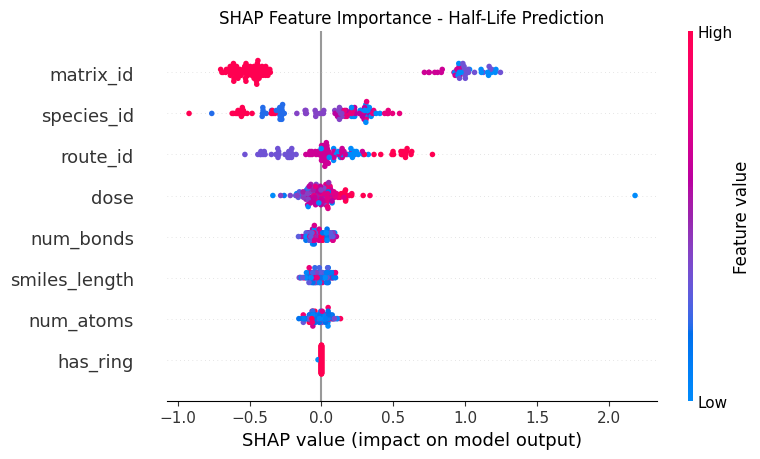

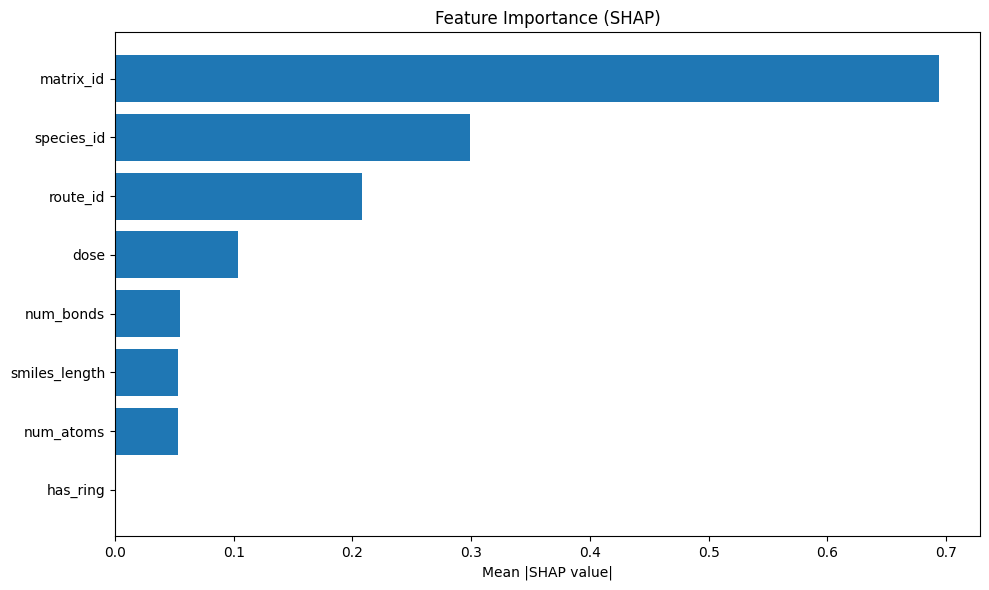

Feature Importance Ranking:
matrix_id: 0.6939
species_id: 0.2993
route_id: 0.2080
dose: 0.1035
num_bonds: 0.0544
smiles_length: 0.0534
num_atoms: 0.0534
has_ring: 0.0002

Sample 1 SHAP explanation:


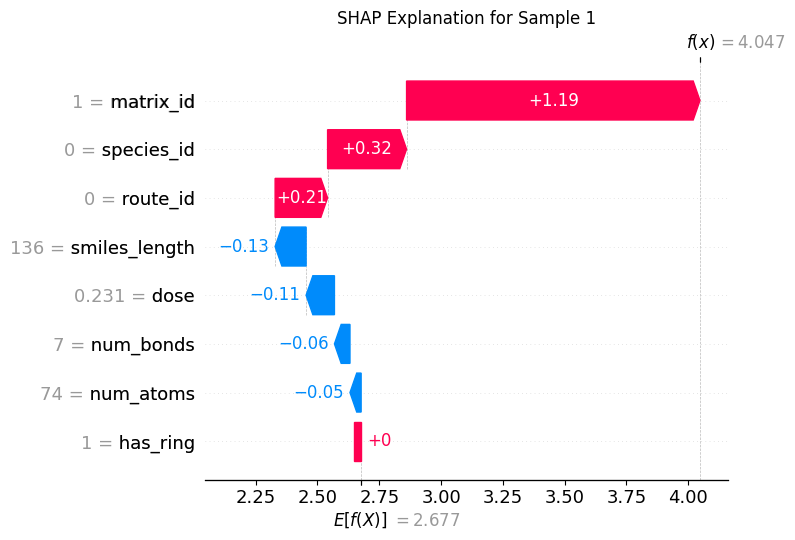


Sample 2 SHAP explanation:


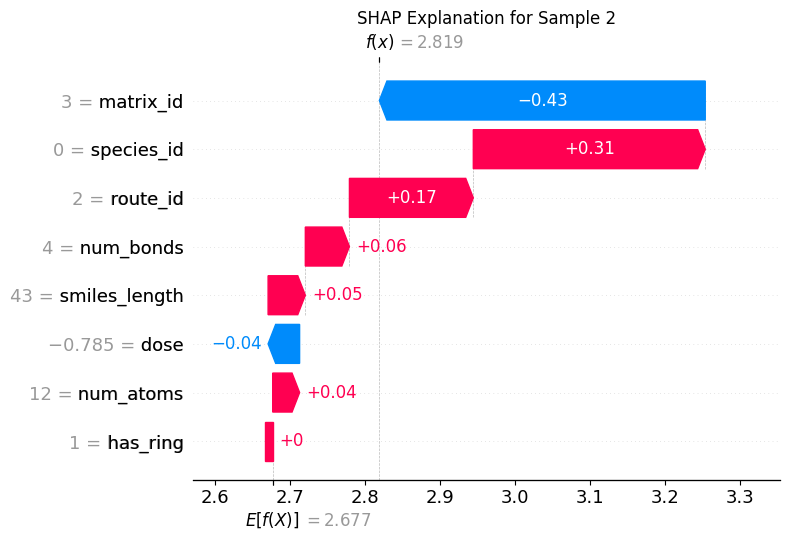


Sample 3 SHAP explanation:


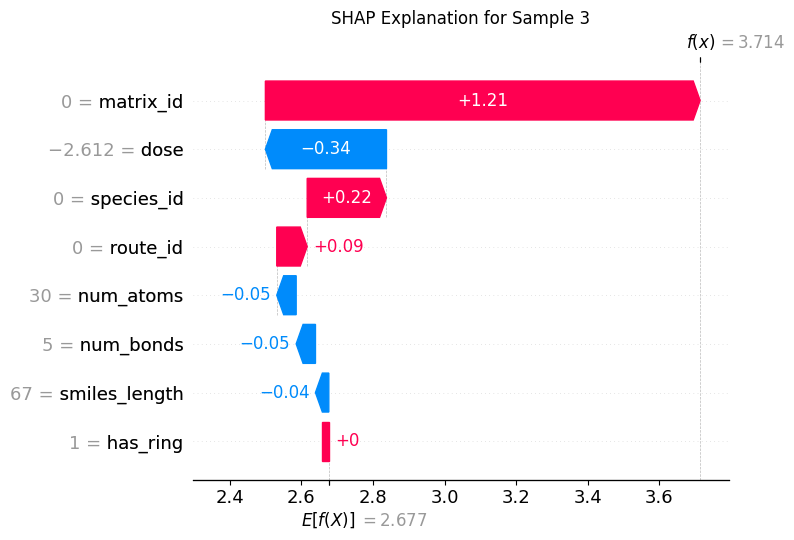

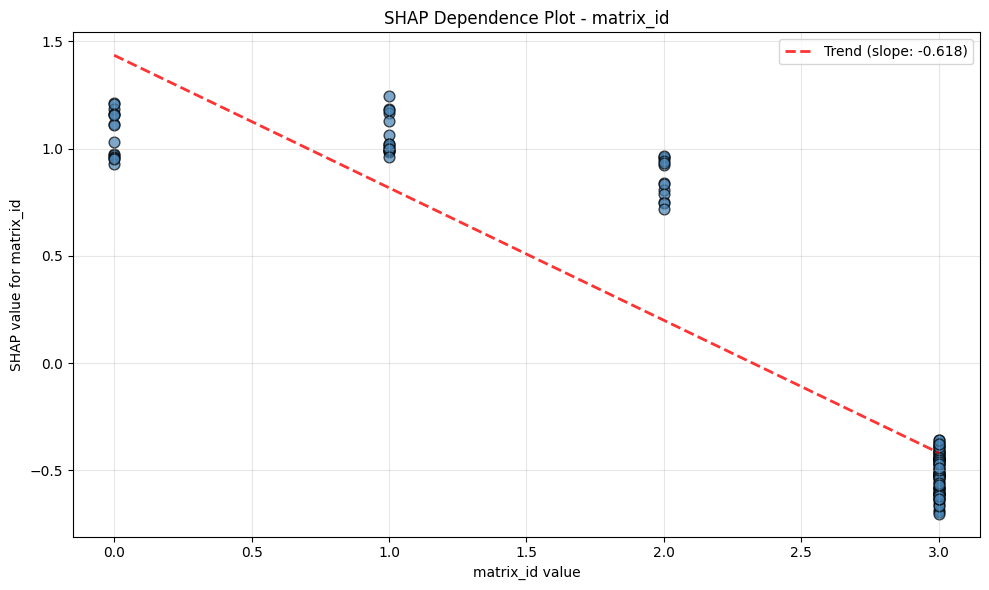

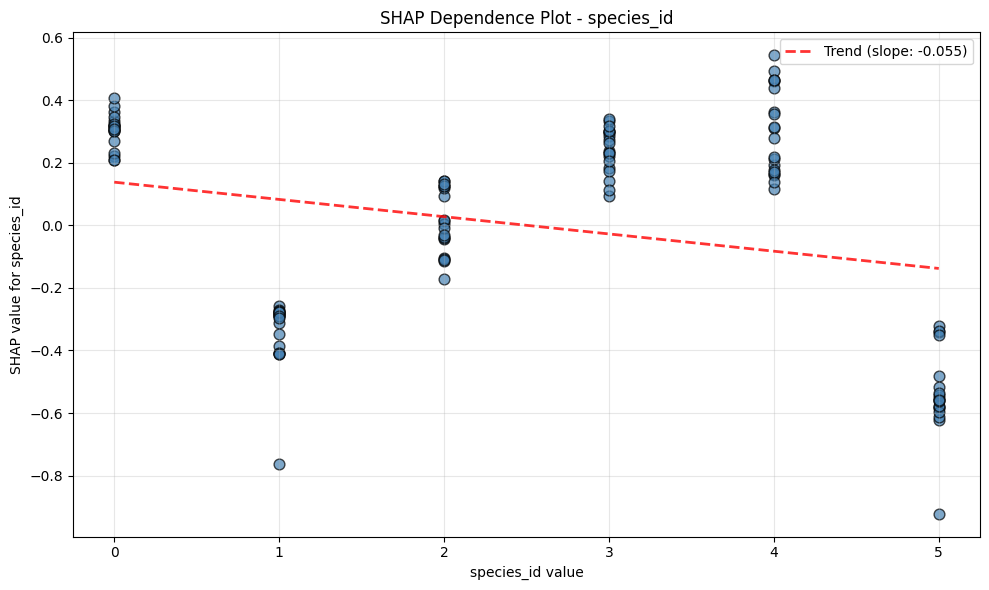

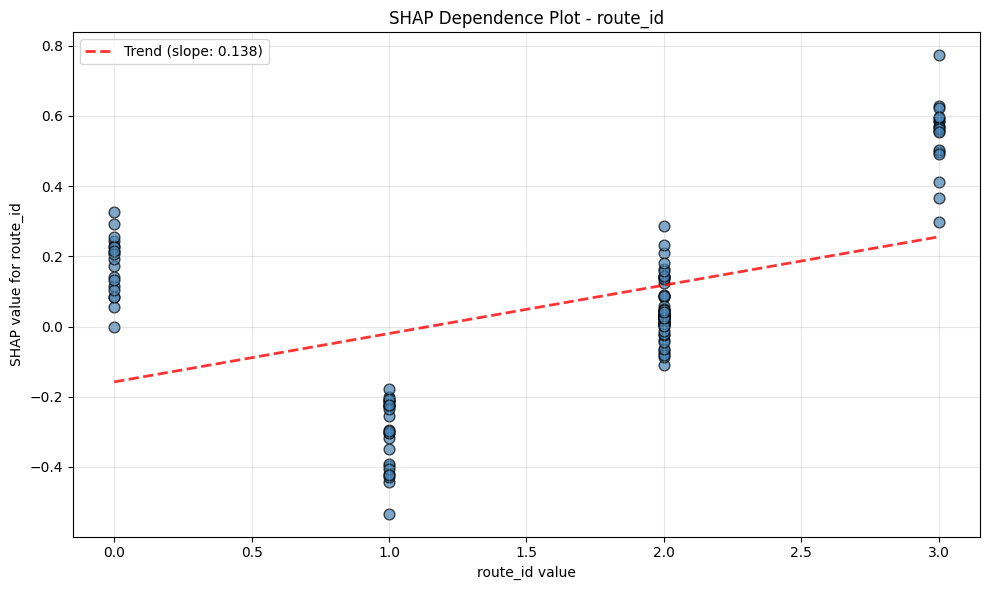

In [25]:
# First, check the shapes of SHAP values and data
print(f"SHAP values shape: {np.array(shap_values_numerical).shape}")
print(f"Test data shape: {test_numerical.values.shape}")

# Handle case where SHAP values might be a list instead of array
if isinstance(shap_values_numerical, list):
    shap_values_array = np.array(shap_values_numerical)
else:
    shap_values_array = shap_values_numerical

# Create visualizations with proper error handling
feature_names = background_numerical.columns.tolist()

# 1. Summary plot (this should work fine)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_array, test_numerical.values,
                  feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance - Half-Life Prediction')
plt.tight_layout()
plt.show()

# 2. Bar plot of mean absolute SHAP values
feature_importance = np.mean(np.abs(shap_values_array), axis=0)
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Mean |SHAP value|')
plt.title('Feature Importance (SHAP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Feature Importance Ranking:")
for idx, row in importance_df.iterrows():
    print(f"{row['feature']}: {row['importance']:.4f}")

# 3. Individual prediction explanations using waterfall plots
for i in range(min(3, len(test_numerical))):
    print(f"\nSample {i+1} SHAP explanation:")

    # Create explanation object for waterfall plot
    try:
        shap_exp = shap.Explanation(
            values=shap_values_array[i],
            base_values=explainer_numerical.expected_value,
            data=test_numerical.values[i],
            feature_names=feature_names
        )

        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap_exp, show=False)
        plt.title(f'SHAP Explanation for Sample {i+1}')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error creating waterfall plot for sample {i+1}: {e}")

# 4. Manual scatter plots for feature dependence (RECOMMENDED)
top_features = importance_df.head(3)['feature'].tolist()

for feature in top_features:
    feature_idx = feature_names.index(feature)

    plt.figure(figsize=(10, 6))

    # Get feature values and corresponding SHAP values
    x_vals = test_numerical.values[:, feature_idx]
    y_vals = shap_values_array[:, feature_idx]

    # Create scatter plot
    plt.scatter(x_vals, y_vals, alpha=0.7, s=60, c='steelblue', edgecolors='black')

    # Add trend line if we have enough points
    if len(x_vals) > 1:
        try:
            z = np.polyfit(x_vals, y_vals, 1)
            p = np.poly1d(z)
            x_trend = np.linspace(x_vals.min(), x_vals.max(), 100)
            plt.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2,
                    label=f'Trend (slope: {z[0]:.3f})')
            plt.legend()
        except:
            pass

    plt.xlabel(f'{feature} value')
    plt.ylabel(f'SHAP value for {feature}')
    plt.title(f'SHAP Dependence Plot - {feature}')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [26]:
def analyze_species_specific_shap(shap_values_array, test_numerical, feature_names, species_list):
    """
    Analyze SHAP values separately for each species
    MODIFIED: Does not skip species with few samples (keeps Turkey)
    """
    species_results = {}

    # Get species IDs for test samples
    species_ids = test_numerical['species_id'].values

    print("\nSpecies-Specific Feature Importance Analysis")
    print("=" * 70)

    # CHANGE: Iterate through ALL species (0-5), not just unique values in data
    for species_id in range(len(species_list)):
        # Get species name
        species_name = species_list[species_id]

        # Filter data for this species
        species_mask = (species_ids == species_id)
        species_shap = shap_values_array[species_mask]
        species_data = test_numerical.values[species_mask]

        # CHANGE: Don't skip if <3 samples, just warn
        if len(species_shap) == 0:
            print(f"\n⚠️  {species_name}: NO SAMPLES - cannot analyze")
            continue  # Only skip if truly zero samples

        if len(species_shap) < 5:
            # Warn but DON'T skip
            print(f"\n⚠️  {species_name}: Only {len(species_shap)} samples - LIMITED RELIABILITY")
        else:
            print(f"\n✅ {species_name}: {len(species_shap)} samples")

        # Calculate feature importance (even for small sample sizes)
        species_importance = np.mean(np.abs(species_shap), axis=0)

        # Create importance dataframe
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': species_importance,
            'mean_shap': np.mean(species_shap, axis=0),
            'std_shap': np.std(species_shap, axis=0)
        }).sort_values('importance', ascending=False)

        species_results[species_name] = {
            'n_samples': len(species_shap),
            'importance_df': importance_df,
            'shap_values': species_shap,
            'feature_data': species_data
        }

        # Print results
        print("-" * 70)
        for i, (_, row) in enumerate(importance_df.head(5).iterrows()):
            direction = "↑" if row['mean_shap'] > 0 else "↓"
            print(f"{i+1:2d}. {row['feature']:15s}: {row['importance']:.4f} {direction}")

    return species_results

# Run species-specific analysis
species_results = analyze_species_specific_shap(
    shap_values_array,
    test_numerical,
    feature_names,
    species_list
)



Species-Specific Feature Importance Analysis

✅ Cattle: 20 samples
----------------------------------------------------------------------
 1. matrix_id      : 0.8888 ↑
 2. species_id     : 0.3043 ↑
 3. route_id       : 0.2463 ↑
 4. dose           : 0.1130 ↓
 5. num_atoms      : 0.0675 ↓

✅ Chickens: 20 samples
----------------------------------------------------------------------
 1. matrix_id      : 0.7274 ↑
 2. species_id     : 0.3406 ↓
 3. route_id       : 0.1207 ↑
 4. dose           : 0.0780 ↓
 5. num_atoms      : 0.0539 ↓

✅ Goats: 20 samples
----------------------------------------------------------------------
 1. matrix_id      : 0.5351 ↓
 2. route_id       : 0.2392 ↑
 3. species_id     : 0.0843 ↑
 4. dose           : 0.0672 ↓
 5. num_bonds      : 0.0479 ↑

✅ Sheep: 20 samples
----------------------------------------------------------------------
 1. matrix_id      : 0.5850 ↓
 2. route_id       : 0.3064 ↑
 3. species_id     : 0.2420 ↑
 4. dose           : 0.1071 ↑
 5. num_atom

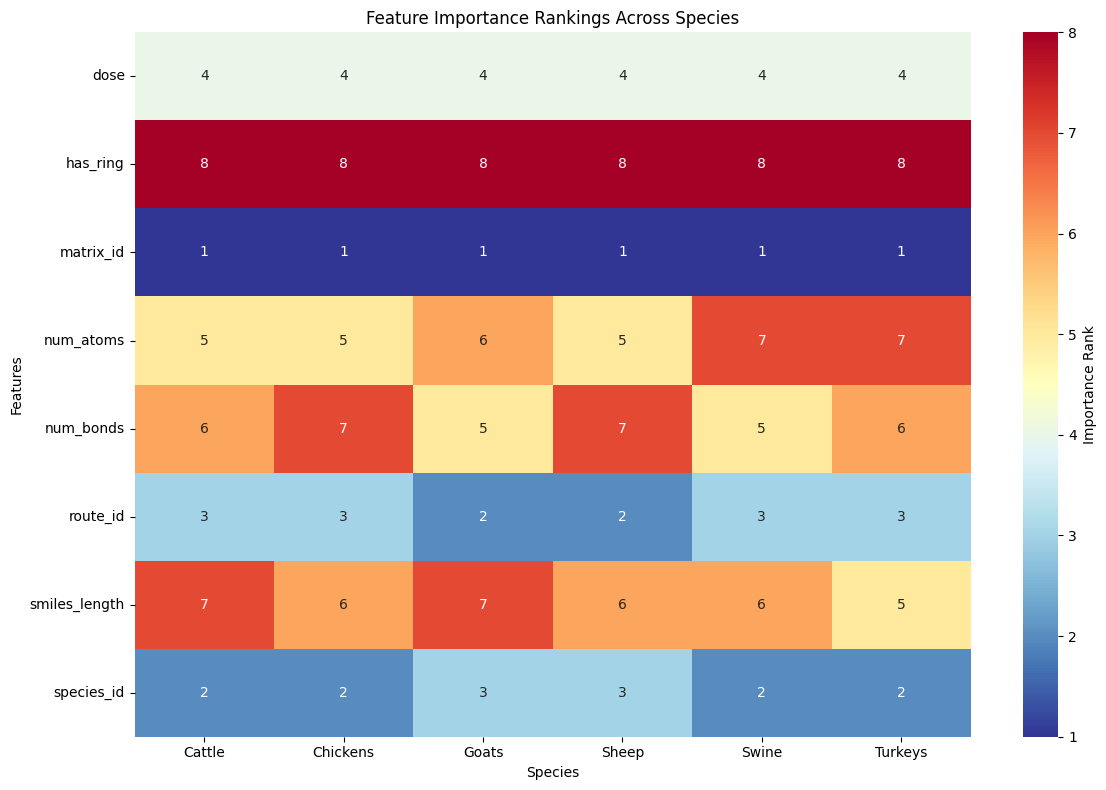


Species-Specific Insights:
dose           : Most important for Turkeys (0.1842)
                 Least important for Goats (0.0672)
route_id       : Most important for Sheep (0.3064)
                 Least important for Chickens (0.1207)
species_id     : Most important for Turkeys (0.5342)
                 Least important for Goats (0.0843)
has_ring       : Most important for Chickens (0.0012)
                 Least important for Cattle (0.0000)


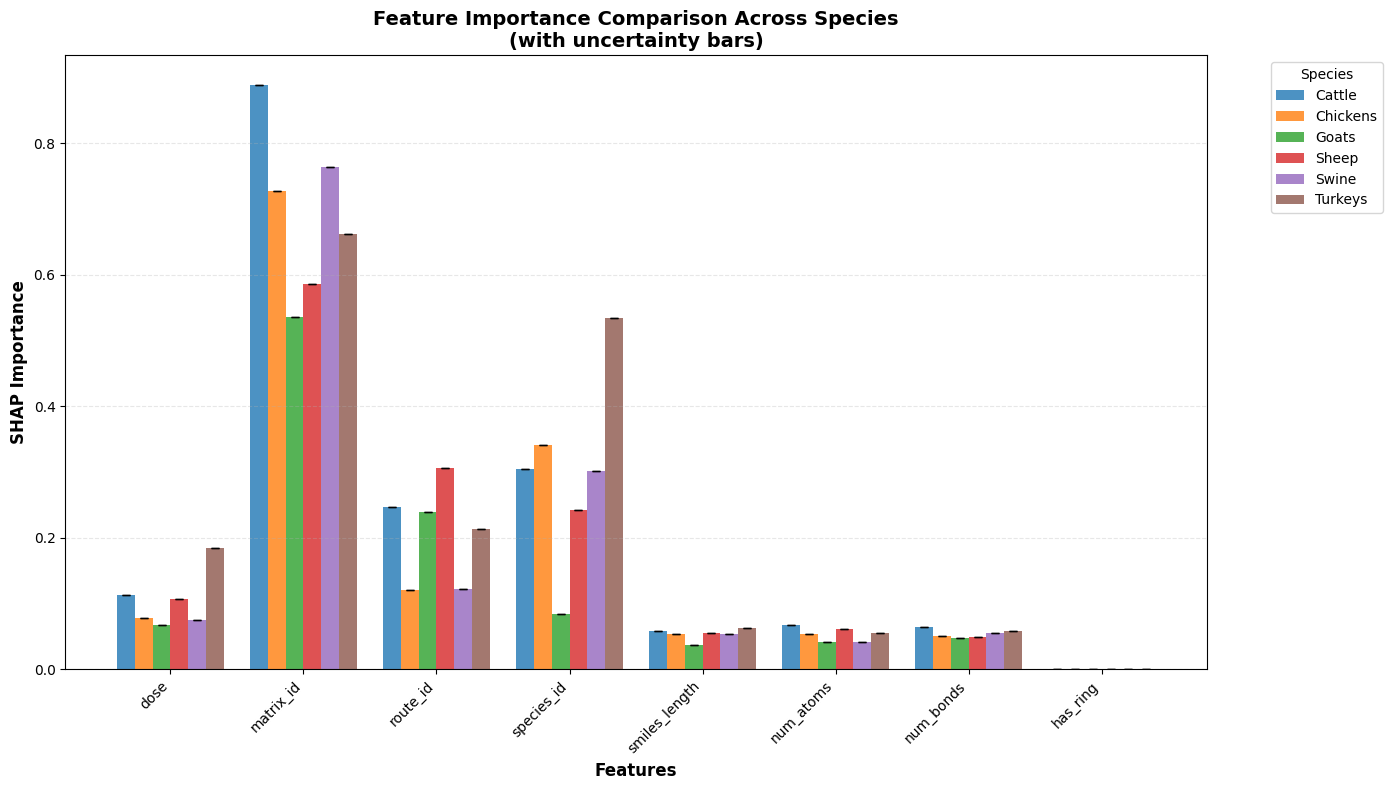


Feature Importance Summary Table:
species          Cattle  Chickens     Goats     Sheep     Swine   Turkeys
feature                                                                  
dose           0.113046  0.077963  0.067184  0.107090  0.075386  0.184158
has_ring       0.000000  0.001199  0.000000  0.000000  0.000000  0.000000
matrix_id      0.888839  0.727406  0.535110  0.585034  0.763841  0.661676
num_atoms      0.067539  0.053901  0.041062  0.060866  0.041846  0.055422
num_bonds      0.064423  0.050713  0.047861  0.049750  0.055983  0.057717
route_id       0.246271  0.120699  0.239178  0.306378  0.122281  0.213616
smiles_length  0.059011  0.053637  0.037702  0.054637  0.053790  0.062252
species_id     0.304333  0.340608  0.084288  0.241982  0.302133  0.534236


In [29]:
def compare_species_importance(species_results):
    """
    Compare feature importance rankings across species
    """
    if len(species_results) < 2:
        print("Need at least 2 species for comparison")
        return

    # Create comparison dataframe
    comparison_data = []
    for species_name, results in species_results.items():
        for _, row in results['importance_df'].iterrows():
            comparison_data.append({
                'species': species_name,
                'feature': row['feature'],
                'importance': row['importance'],
                'rank': results['importance_df'].index.get_loc(_) + 1
            })

    comparison_df = pd.DataFrame(comparison_data)

    # Create heatmap of importance rankings
    pivot_df = comparison_df.pivot(index='feature', columns='species', values='rank')

    plt.figure(figsize=(12, 8))
    import seaborn as sns
    sns.heatmap(pivot_df, annot=True, cmap='RdYlBu_r', fmt='g',
                cbar_kws={'label': 'Importance Rank'})
    plt.title('Feature Importance Rankings Across Species')
    plt.xlabel('Species')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

    # Print species differences
    print("\nSpecies-Specific Insights:")
    print("=" * 50)

    for feature in feature_names:
        feature_data = comparison_df[comparison_df['feature'] == feature]
        if len(feature_data) > 1:
            max_species = feature_data.loc[feature_data['importance'].idxmax(), 'species']
            min_species = feature_data.loc[feature_data['importance'].idxmin(), 'species']
            max_imp = feature_data['importance'].max()
            min_imp = feature_data['importance'].min()

            if max_imp > 2 * min_imp:  # Significant difference
                print(f"{feature:15s}: Most important for {max_species} ({max_imp:.4f})")
                print(f"{'':<15s}  Least important for {min_species} ({min_imp:.4f})")

# Run comparison
compare_species_importance(species_results)
importance_table = plot_species_importance_with_uncertainty(
    species_results, species_list, feature_names
)

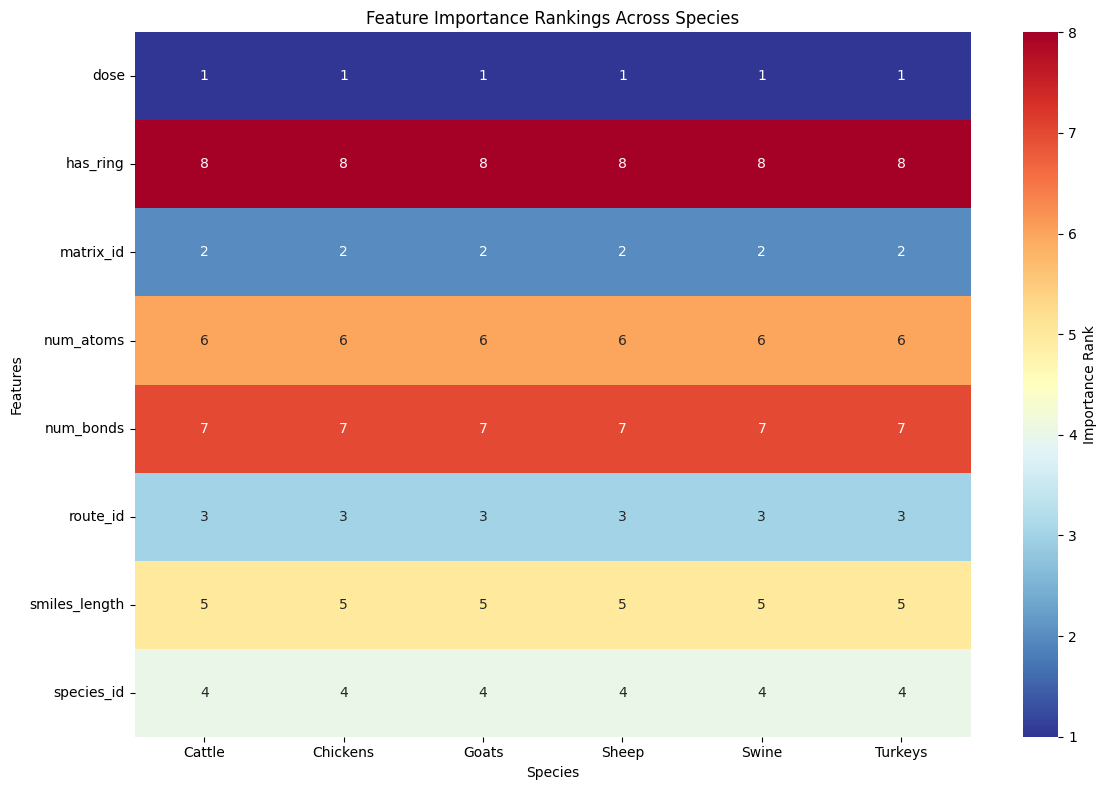


Species-Specific Insights:
dose           : Most important for Turkeys (0.1842)
                 Least important for Goats (0.0672)
route_id       : Most important for Sheep (0.3064)
                 Least important for Chickens (0.1207)
species_id     : Most important for Turkeys (0.5342)
                 Least important for Goats (0.0843)
has_ring       : Most important for Chickens (0.0012)
                 Least important for Cattle (0.0000)


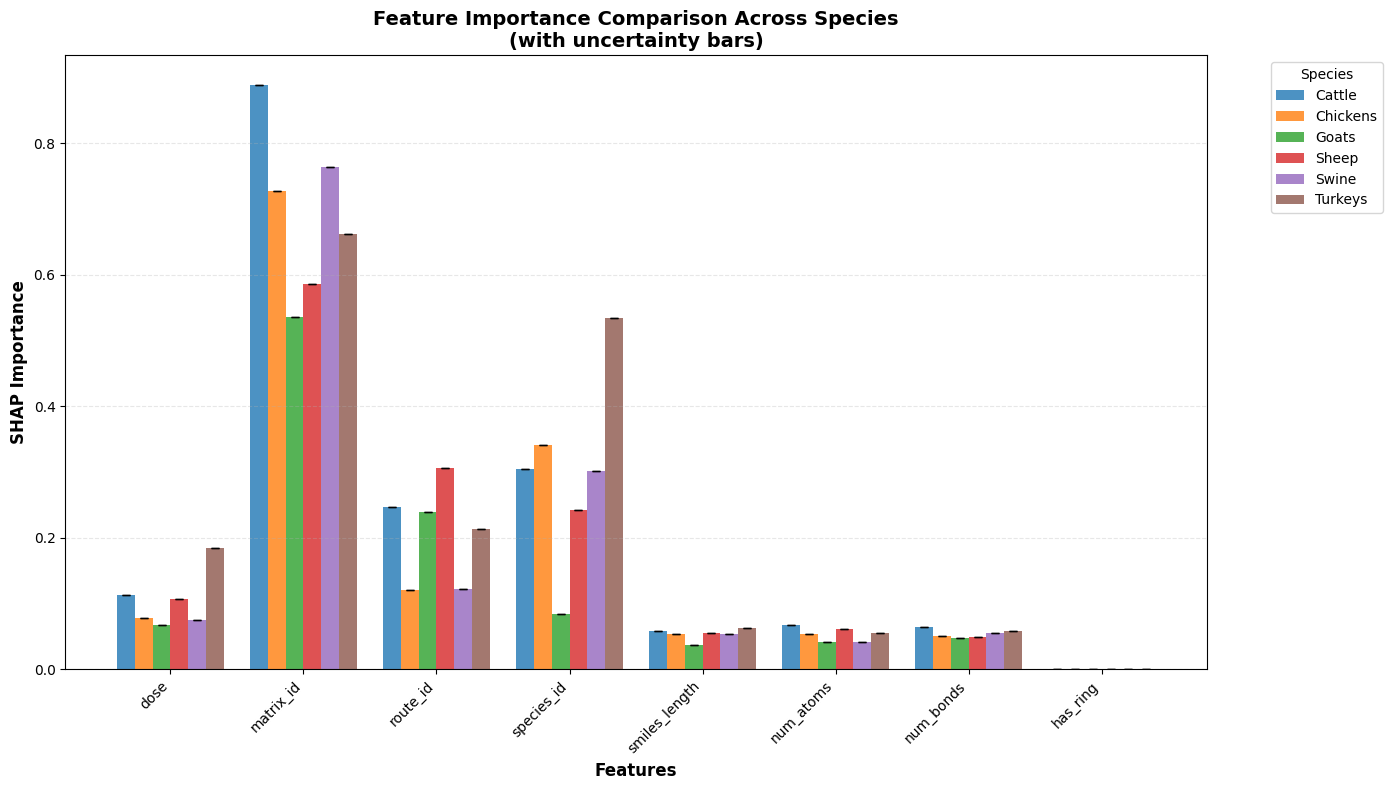


Feature Importance Summary Table:
species          Cattle  Chickens     Goats     Sheep     Swine   Turkeys
feature                                                                  
dose           0.113046  0.077963  0.067184  0.107090  0.075386  0.184158
has_ring       0.000000  0.001199  0.000000  0.000000  0.000000  0.000000
matrix_id      0.888839  0.727406  0.535110  0.585034  0.763841  0.661676
num_atoms      0.067539  0.053901  0.041062  0.060866  0.041846  0.055422
num_bonds      0.064423  0.050713  0.047861  0.049750  0.055983  0.057717
route_id       0.246271  0.120699  0.239178  0.306378  0.122281  0.213616
smiles_length  0.059011  0.053637  0.037702  0.054637  0.053790  0.062252
species_id     0.304333  0.340608  0.084288  0.241982  0.302133  0.534236


In [28]:
def compare_species_importance(species_results):
    """
    Compare feature importance rankings across species
    """
    if len(species_results) < 2:
        print("Need at least 2 species for comparison")
        return

    # Create comparison dataframe
    comparison_data = []
    for species_name, results in species_results.items():
        for idx, row in results['importance_df'].iterrows():
            comparison_data.append({
                'species': species_name,
                'feature': row['feature'],
                'importance': row['importance'],
                'rank': idx + 1
            })

    comparison_df = pd.DataFrame(comparison_data)

    # Create heatmap of importance rankings
    pivot_df = comparison_df.pivot(index='feature', columns='species', values='rank')

    plt.figure(figsize=(12, 8))
    import seaborn as sns
    sns.heatmap(pivot_df, annot=True, cmap='RdYlBu_r', fmt='g',
                cbar_kws={'label': 'Importance Rank'})
    plt.title('Feature Importance Rankings Across Species')
    plt.xlabel('Species')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

    # Print species differences
    print("\nSpecies-Specific Insights:")
    print("=" * 50)

    for feature in feature_names:
        feature_data = comparison_df[comparison_df['feature'] == feature]
        if len(feature_data) > 1:
            max_species = feature_data.loc[feature_data['importance'].idxmax(), 'species']
            min_species = feature_data.loc[feature_data['importance'].idxmin(), 'species']
            max_imp = feature_data['importance'].max()
            min_imp = feature_data['importance'].min()

            if max_imp > 2 * min_imp:  # Significant difference
                print(f"{feature:15s}: Most important for {max_species} ({max_imp:.4f})")
                print(f"{'':<15s}  Least important for {min_species} ({min_imp:.4f})")


def plot_species_importance_with_uncertainty(species_results, species_list, feature_names):
    """
    Plot feature importance with uncertainty (standard deviation) across species
    """
    # Prepare data for plotting
    plot_data = []

    for species_name in species_list:
        if species_name in species_results:
            results = species_results[species_name]
            importance_df = results['importance_df']

            for _, row in importance_df.iterrows():
                plot_data.append({
                    'species': species_name,
                    'feature': row['feature'],
                    'importance': row['importance'],
                    'std': row.get('std', 0)  # Get std if available, else 0
                })

    plot_df = pd.DataFrame(plot_data)

    # Create grouped bar plot
    fig, ax = plt.subplots(figsize=(14, 8))

    # Set up positions for grouped bars
    n_species = len(species_list)
    n_features = len(feature_names)
    bar_width = 0.8 / n_species
    x = np.arange(n_features)

    # Plot bars for each species
    for i, species_name in enumerate(species_list):
        if species_name in species_results:
            species_data = plot_df[plot_df['species'] == species_name]

            # Ensure features are in the correct order
            ordered_data = []
            ordered_std = []
            for feature in feature_names:
                feat_data = species_data[species_data['feature'] == feature]
                if not feat_data.empty:
                    ordered_data.append(feat_data['importance'].values[0])
                    ordered_std.append(feat_data['std'].values[0])
                else:
                    ordered_data.append(0)
                    ordered_std.append(0)

            # Plot with error bars
            ax.bar(x + i * bar_width, ordered_data, bar_width,
                   label=species_name, yerr=ordered_std, capsize=3, alpha=0.8)

    # Formatting
    ax.set_xlabel('Features', fontsize=12, fontweight='bold')
    ax.set_ylabel('SHAP Importance', fontsize=12, fontweight='bold')
    ax.set_title('Feature Importance Comparison Across Species\n(with uncertainty bars)',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x + bar_width * (n_species - 1) / 2)
    ax.set_xticklabels(feature_names, rotation=45, ha='right')
    ax.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

    # Create summary table
    summary_table = plot_df.pivot_table(
        index='feature',
        columns='species',
        values='importance',
        aggfunc='mean'
    )

    print("\nFeature Importance Summary Table:")
    print("=" * 80)
    print(summary_table.to_string())

    return summary_table


# Run comparison
compare_species_importance(species_results)
importance_table = plot_species_importance_with_uncertainty(
    species_results, species_list, feature_names
)

In [30]:
def plot_species_importance_with_uncertainty(species_results, species_list, feature_names):
    """
    Plot feature importance for ALL 6 species with uncertainty quantification
    Includes visual warnings for species with limited samples (Turkey)
    """
    from scipy.stats import bootstrap
    import seaborn as sns

    print("\n" + "="*70)
    print("PLOTTING ALL 6 SPECIES WITH UNCERTAINTY")
    print("="*70)

    # Prepare importance matrix for all species
    n_features = len(feature_names)
    n_species = len(species_list)
    importance_matrix = np.zeros((n_features, n_species))
    error_matrix = np.zeros((n_features, n_species))  # For error bars

    for species_id, species_name in enumerate(species_list):
        if species_name in species_results:
            species_data = species_results[species_name]
            importance_matrix[:, species_id] = species_data['importance_df']['importance'].values

            # Calculate bootstrap confidence intervals for uncertainty
            species_shap = species_data['shap_values']
            n_samples = len(species_shap)

            if n_samples >= 2:
                # Bootstrap standard error
                boot_importance = []
                n_boot = 500
                for _ in range(n_boot):
                    boot_idx = np.random.choice(n_samples, size=n_samples, replace=True)
                    boot_shap = species_shap[boot_idx]
                    boot_importance.append(np.mean(np.abs(boot_shap), axis=0))

                boot_importance = np.array(boot_importance)
                error_matrix[:, species_id] = boot_importance.std(axis=0)

                print(f"{species_name:10s}: n={n_samples:3d}, avg SE={error_matrix[:, species_id].mean():.4f}")
            else:
                error_matrix[:, species_id] = 0
                print(f"{species_name:10s}: n={n_samples:3d}, SE=N/A")
        else:
            print(f"{species_name:10s}: NO DATA")

    # Create the plot
    fig, ax = plt.subplots(figsize=(16, 9))

    x = np.arange(n_features)
    width = 0.13  # Bar width for 6 species

    # Define colors for all 6 species
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

    for i, (species_name, color) in enumerate(zip(species_list, colors)):
        offset = (i - 2.5) * width
        values = importance_matrix[:, i]
        errors = error_matrix[:, i]

        if species_name in species_results:
            n_samples = species_results[species_name]['n_samples']

            # Visual distinction for low-sample species (Turkey)
            if n_samples < 30:
                # Use hatching and error bars for Turkey
                label = f'{species_name}* (n={n_samples})'
                alpha = 0.6
                hatch = '///'
                edgecolor = 'red'
                linewidth = 2

                # Add error bars for Turkey
                ax.bar(x + offset, values, width, yerr=errors,
                       label=label, color=color, alpha=alpha,
                       edgecolor=edgecolor, linewidth=linewidth, hatch=hatch,
                       error_kw={'linewidth': 2, 'ecolor': 'red', 'capsize': 4})
            else:
                # Standard bars for well-sampled species
                label = f'{species_name} (n={n_samples})'
                ax.bar(x + offset, values, width, label=label,
                       color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
        else:
            # Placeholder for missing species (should not happen with stratified)
            label = f'{species_name} (NO DATA)'
            ax.bar(x + offset, values, width, label=label,
                   color=color, alpha=0.2, edgecolor='gray', linewidth=0.5)

    # Formatting
    ax.set_xlabel('Features', fontsize=14, fontweight='bold')
    ax.set_ylabel('Mean |SHAP Value|', fontsize=14, fontweight='bold')
    ax.set_title('Feature Importance Rankings Across All Six Species\n(Stratified Sampling with Uncertainty Quantification)',
                 fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=12)
    ax.legend(ncol=2, loc='upper right', fontsize=10, framealpha=0.95)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add prominent footnote for Turkey
    footnote_text = (
        '*Limited sample size (n<30): Error bars show bootstrap standard error.\n'
        'Interpret rankings with caution due to higher uncertainty.'
    )
    ax.text(0.02, 0.98, footnote_text,
            transform=ax.transAxes, fontsize=10,
            verticalalignment='top', style='italic',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.4, edgecolor='red'))

    plt.tight_layout()
    plt.savefig('Figure_3C_Stratified_With_Uncertainty.tif', dpi=300, bbox_inches='tight')
    plt.show()

    # Print summary table
    print("\n" + "="*70)
    print("FEATURE IMPORTANCE TABLE (All 6 Species)")
    print("="*70)
    importance_df = pd.DataFrame(
        importance_matrix,
        index=feature_names,
        columns=species_list
    )
    print(importance_df.round(4))

    # Print sample size summary
    print("\n" + "="*70)
    print("SAMPLE SIZES")
    print("="*70)
    for species_name in species_list:
        if species_name in species_results:
            n = species_results[species_name]['n_samples']
            status = "⚠️" if n < 30 else "✅"
            print(f"{status} {species_name:10s}: {n:3d} samples")
        else:
            print(f"❌ {species_name:10s}:  NO DATA")

    print("="*70)
    return importance_df


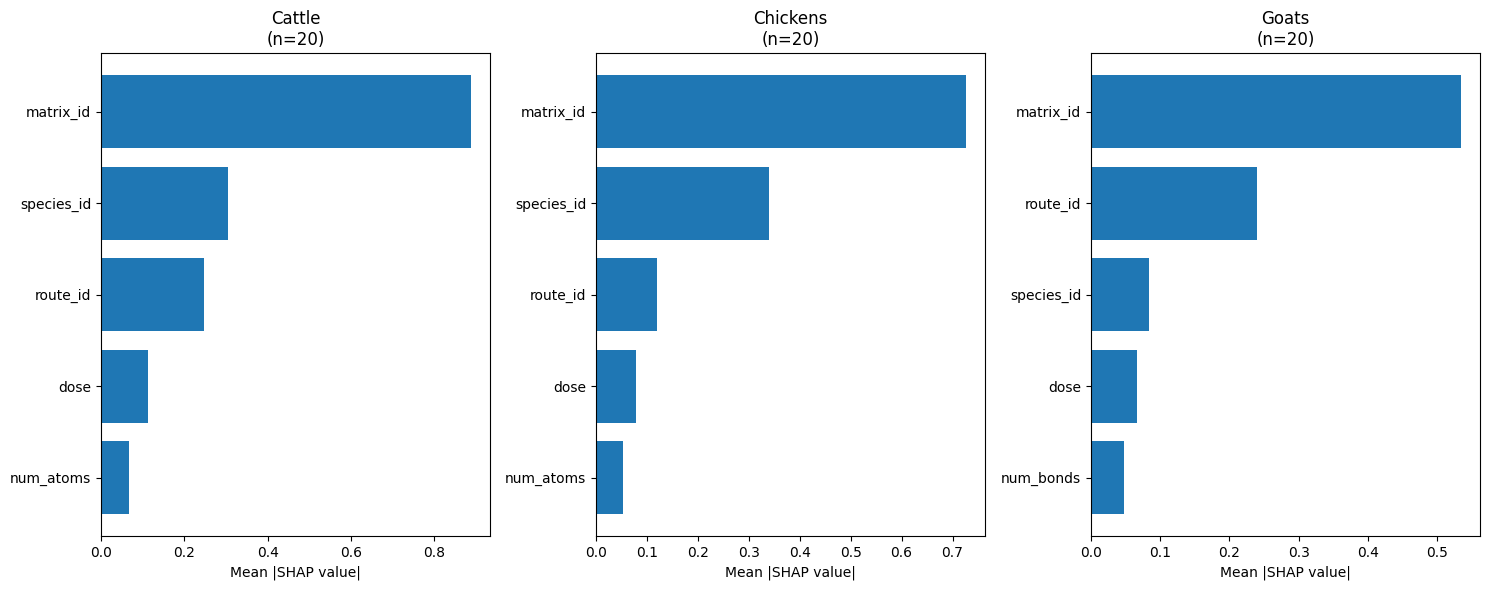

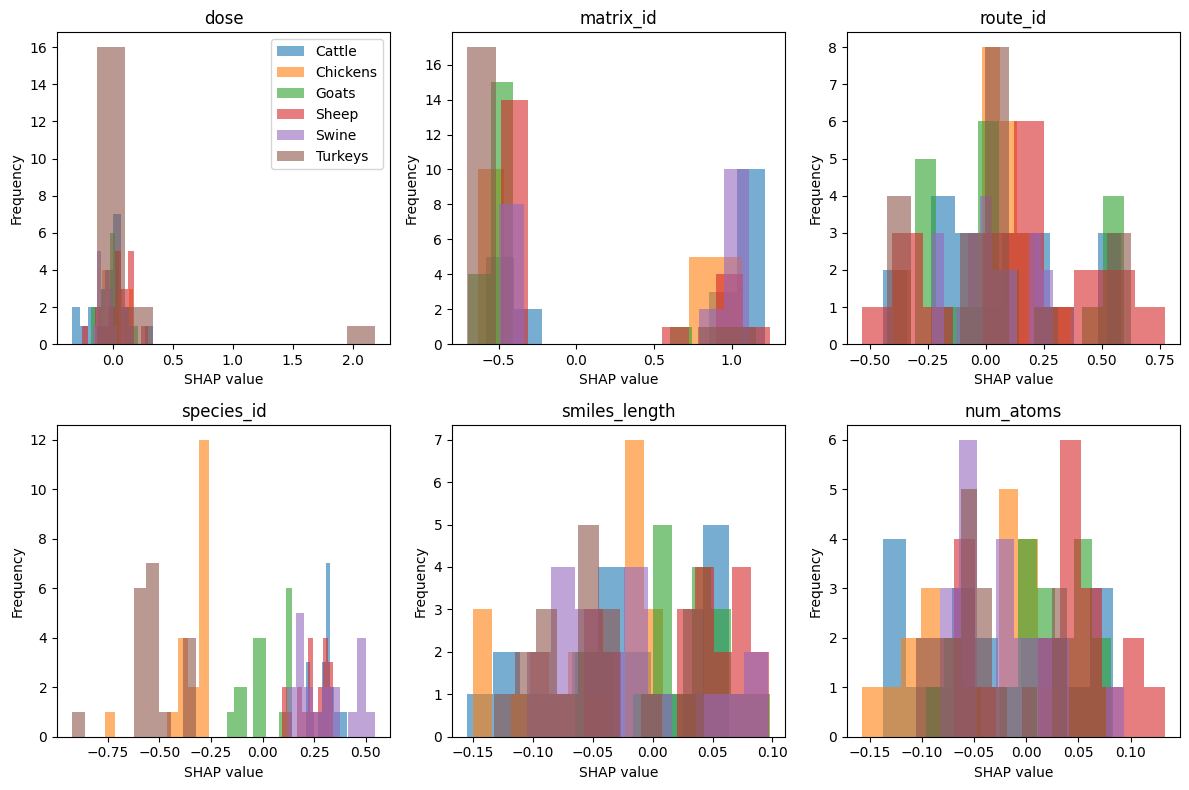

In [31]:
def visualize_species_shap(species_results, top_n_features=5):
    """
    Create species-specific SHAP visualizations
    """
    n_species = len(species_results)
    if n_species == 0:
        return

    # 1. Species comparison bar plot
    fig, axes = plt.subplots(1, min(n_species, 3), figsize=(15, 6))
    if n_species == 1:
        axes = [axes]

    for i, (species_name, results) in enumerate(list(species_results.items())[:3]):
        ax = axes[i] if i < len(axes) else axes[-1]

        top_features = results['importance_df'].head(top_n_features)
        ax.barh(top_features['feature'], top_features['importance'])
        ax.set_title(f'{species_name}\n(n={results["n_samples"]})')
        ax.set_xlabel('Mean |SHAP value|')
        ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # 2. Feature contribution patterns
    plt.figure(figsize=(12, 8))
    species_names = list(species_results.keys())

    for feature_idx, feature in enumerate(feature_names[:6]):  # Top 6 features
        plt.subplot(2, 3, feature_idx + 1)

        for species_name in species_names:
            if species_name in species_results:
                results = species_results[species_name]
                shap_vals = results['shap_values'][:, feature_names.index(feature)]
                plt.hist(shap_vals, alpha=0.6, label=species_name, bins=10)

        plt.title(f'{feature}')
        plt.xlabel('SHAP value')
        plt.ylabel('Frequency')
        if feature_idx == 0:
            plt.legend()

    plt.tight_layout()

    plt.show()

# Create visualizations
visualize_species_shap(species_results)


In [32]:
def test_species_differences(species_results, feature_name):
    """
    Test if feature importance differs significantly across species
    """
    from scipy import stats

    species_shap_values = []
    species_names = []

    for species_name, results in species_results.items():
        if results['n_samples'] >= 5:  # Minimum sample size
            feature_idx = feature_names.index(feature_name)
            shap_vals = results['shap_values'][:, feature_idx]
            species_shap_values.append(shap_vals)
            species_names.append(species_name)

    if len(species_shap_values) >= 2:
        # Perform ANOVA test
        f_stat, p_value = stats.f_oneway(*species_shap_values)

        print(f"\n{feature_name} - Species Difference Test:")
        print(f"F-statistic: {f_stat:.4f}")
        print(f"P-value: {p_value:.4f}")
        print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")

        return f_stat, p_value

    return None, None

# Test key features
for feature in ['dose', 'matrix_id', 'route_id']:
    test_species_differences(species_results, feature)



dose - Species Difference Test:
F-statistic: 1.5494
P-value: 0.1802
Significant difference: No

matrix_id - Species Difference Test:
F-statistic: 8.9434
P-value: 0.0000
Significant difference: Yes

route_id - Species Difference Test:
F-statistic: 0.4176
P-value: 0.8357
Significant difference: No


Uncertainty Quantification

In [33]:
def mc_dropout_predictions(model, data_loader, device, n_iter=50):
    """
    Monte Carlo Dropout for Uncertainty Quantification

    Args:
        model: trained HybridMultiTaskModel with dropout layers
        data_loader: DataLoader with test/validation data
        device: torch device ('cpu' or 'cuda')
        n_iter: Number of stochastic forward passes

    Returns:
        preds_mean: Mean predictions (num_samples,)
        preds_std: Standard deviation (uncertainty) of predictions (num_samples,)
        all_predictions: Raw predictions from all iterations (n_iter, num_samples)
    """
    # Enable dropout during inference by setting to train mode
    model.train()

    all_preds = []
    all_species_ids = []

    for iteration in range(n_iter):
        batch_preds = []
        batch_species = []

        with torch.no_grad():
            for batch in data_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                matrix_id = batch['matrix_id'].to(device)
                route_id = batch['route_id'].to(device)
                dose = batch['dose'].to(device).float()
                species_id = batch['species_id'].to(device)

                # Forward pass with dropout enabled
                logits = model(input_ids, attention_mask, matrix_id, route_id, dose)

                # Gather predictions for correct species
                preds = logits.gather(1, species_id.view(-1, 1)).squeeze(1)

                batch_preds.append(preds.cpu().numpy())
                if iteration == 0:  # Store species IDs only once
                    batch_species.append(species_id.cpu().numpy())

        # Concatenate all batches for this iteration
        iter_preds = np.concatenate(batch_preds)
        all_preds.append(iter_preds)

        if iteration == 0:
            all_species_ids = np.concatenate(batch_species)

    # Convert to numpy array: shape (n_iter, num_samples)
    all_preds = np.array(all_preds)

    # Calculate mean and standard deviation
    preds_mean = all_preds.mean(axis=0)
    preds_std = all_preds.std(axis=0)

    # Reset model to evaluation mode
    model.eval()

    return preds_mean, preds_std, all_preds, all_species_ids

# Usage
print("Performing Monte Carlo Dropout for Uncertainty Quantification...")
preds_mean, preds_std, all_predictions, species_ids = mc_dropout_predictions(
    model, test_loader, device, n_iter=100
)

print(f"Shape of predictions: {preds_mean.shape}")
print(f"Mean prediction uncertainty (std): {np.mean(preds_std):.4f}")


Performing Monte Carlo Dropout for Uncertainty Quantification...
Shape of predictions: (401,)
Mean prediction uncertainty (std): 0.4320


In [34]:
def train_ensemble_models(train_loader, val_loader, n_models=5):
    """
    Train multiple models with different initializations for ensemble uncertainty
    """
    ensemble_models = []

    for i in range(n_models):
        print(f"Training ensemble model {i+1}/{n_models}")

        # Create new model with different random initialization
        ensemble_model = HybridMultiTaskModel(
            num_species=num_species,
            num_matrices=int(train_df_al["matrix_id"].max()+1),
            num_routes=int(train_df_al["route_id"].max()+1),
            matrix_emb_dim=MATRIX_EMB_DIM,
            route_emb_dim=ROUTE_EMB_DIM,
            hidden_size=HIDDEN_SIZE,
            dropout_rate=DROPOUT_RATE,
            chemberta_name=MODEL_NAME,
            tokenizer=tokenizer
        ).to(device)

        # Train the model (abbreviated - use existing training loop)
        optimizer = AdamW([
            {"params": ensemble_model.chemberta.parameters(), "lr": BERT_LR},
            {"params": head_params, "lr": HEAD_LR},
        ], weight_decay=WEIGHT_DECAY)

        # Training loop here...
        # train_model(ensemble_model, optimizer, train_loader, val_loader)

        ensemble_models.append(ensemble_model)

    return ensemble_models

def ensemble_predictions(models, data_loader, device):
    """
    Get predictions from ensemble of models
    """
    all_model_preds = []

    for model_idx, model in enumerate(models):
        model.eval()
        model_preds = []

        with torch.no_grad():
            for batch in data_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                matrix_id = batch['matrix_id'].to(device)
                route_id = batch['route_id'].to(device)
                dose = batch['dose'].to(device).float()
                species_id = batch['species_id'].to(device)

                logits = model(input_ids, attention_mask, matrix_id, route_id, dose)
                preds = logits.gather(1, species_id.view(-1, 1)).squeeze(1)
                model_preds.append(preds.cpu().numpy())

        model_preds = np.concatenate(model_preds)
        all_model_preds.append(model_preds)

    # Shape: (n_models, n_samples)
    all_model_preds = np.array(all_model_preds)

    # Calculate ensemble statistics
    preds_mean = all_model_preds.mean(axis=0)
    preds_std = all_model_preds.std(axis=0)

    return preds_mean, preds_std, all_model_preds

# Usage (if you have ensemble models)
# ensemble_models = train_ensemble_models(train_loader, val_loader, n_models=5)
# ensemble_mean, ensemble_std, _ = ensemble_predictions(ensemble_models, test_loader, device)


In [35]:
def calculate_prediction_intervals(predictions_mean, predictions_std, confidence=0.95):
    """
    Calculate prediction intervals assuming normal distribution
    """
    from scipy import stats

    # Calculate z-score for confidence level
    alpha = 1 - confidence
    z_score = stats.norm.ppf(1 - alpha/2)

    # Calculate prediction intervals
    lower_bound = predictions_mean - z_score * predictions_std
    upper_bound = predictions_mean + z_score * predictions_std

    return lower_bound, upper_bound

# Calculate 95% prediction intervals
lower_95, upper_95 = calculate_prediction_intervals(preds_mean, preds_std, confidence=0.95)

# Create results dataframe
uncertainty_results = pd.DataFrame({
    'prediction_mean': preds_mean,
    'prediction_std': preds_std,
    'lower_95': lower_95,
    'upper_95': upper_95,
    'species_id': species_ids
})

print("Uncertainty Analysis Results:")
print(uncertainty_results.head(10))


Uncertainty Analysis Results:
   prediction_mean  prediction_std  lower_95  upper_95  species_id
0         0.615716        0.253302  0.119253  1.112178           3
1         2.541910        0.380468  1.796207  3.287613           4
2         4.338109        0.505379  3.347584  5.328635           4
3         3.543798        0.365267  2.827888  4.259707           3
4         2.682278        0.374865  1.947556  3.417000           0
5         0.322779        0.378305 -0.418686  1.064245           2
6         3.419610        0.395293  2.644850  4.194370           1
7         4.712389        0.586643  3.562590  5.862187           4
8         1.541373        0.242925  1.065249  2.017496           2
9         0.391398        0.527328 -0.642146  1.424942           4


In [36]:
def analyze_uncertainty_by_species(uncertainty_results, species_list):
    """
    Analyze prediction uncertainty separately for each species
    """
    species_uncertainty = {}

    for species_id in np.unique(uncertainty_results['species_id']):
        species_name = species_list[species_id] if species_id < len(species_list) else f"Species_{species_id}"
        species_mask = uncertainty_results['species_id'] == species_id
        species_data = uncertainty_results[species_mask]

        if len(species_data) < 3:
            continue

        species_uncertainty[species_name] = {
            'n_samples': len(species_data),
            'mean_uncertainty': species_data['prediction_std'].mean(),
            'median_uncertainty': species_data['prediction_std'].median(),
            'max_uncertainty': species_data['prediction_std'].max(),
            'uncertainty_cv': species_data['prediction_std'].std() / species_data['prediction_std'].mean()
        }

        print(f"\n{species_name} Uncertainty Analysis:")
        print(f"  Samples: {species_uncertainty[species_name]['n_samples']}")
        print(f"  Mean uncertainty: {species_uncertainty[species_name]['mean_uncertainty']:.4f}")
        print(f"  Median uncertainty: {species_uncertainty[species_name]['median_uncertainty']:.4f}")
        print(f"  Max uncertainty: {species_uncertainty[species_name]['max_uncertainty']:.4f}")

    return species_uncertainty

# Run species-specific uncertainty analysis
species_uncertainty = analyze_uncertainty_by_species(uncertainty_results, species_list)



Cattle Uncertainty Analysis:
  Samples: 118
  Mean uncertainty: 0.4321
  Median uncertainty: 0.4305
  Max uncertainty: 0.8791

Chickens Uncertainty Analysis:
  Samples: 70
  Mean uncertainty: 0.3823
  Median uncertainty: 0.3495
  Max uncertainty: 0.8365

Goats Uncertainty Analysis:
  Samples: 38
  Mean uncertainty: 0.3914
  Median uncertainty: 0.3766
  Max uncertainty: 0.6402

Sheep Uncertainty Analysis:
  Samples: 77
  Mean uncertainty: 0.4699
  Median uncertainty: 0.4442
  Max uncertainty: 0.8303

Swine Uncertainty Analysis:
  Samples: 79
  Mean uncertainty: 0.4679
  Median uncertainty: 0.4654
  Max uncertainty: 0.7542

Turkeys Uncertainty Analysis:
  Samples: 19
  Mean uncertainty: 0.3921
  Median uncertainty: 0.3347
  Max uncertainty: 1.0704


/tmp/ipython-input-1202124298.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(uncertainty_by_species, labels=labels)


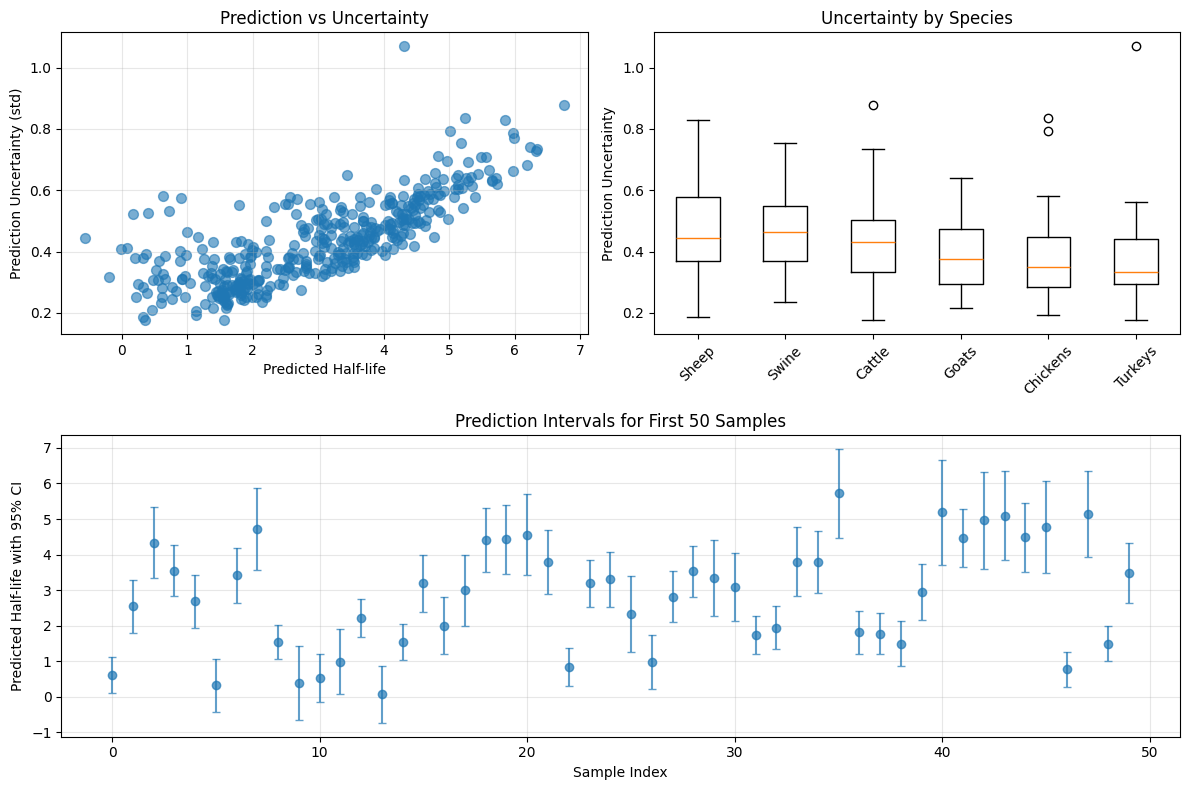

In [37]:
def visualize_uncertainty_analysis(uncertainty_results, species_list):
    """
    Create comprehensive uncertainty visualizations
    """

    # 1. Prediction vs Uncertainty scatter plot
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.scatter(uncertainty_results['prediction_mean'], uncertainty_results['prediction_std'],
                alpha=0.6, s=50)
    plt.xlabel('Predicted Half-life')
    plt.ylabel('Prediction Uncertainty (std)')
    plt.title('Prediction vs Uncertainty')
    plt.grid(True, alpha=0.3)

    # 2. Uncertainty distribution by species
    plt.subplot(2, 2, 2)
    species_ids = uncertainty_results['species_id'].unique()
    uncertainty_by_species = []
    labels = []

    for species_id in species_ids:
        if species_id < len(species_list):
            species_mask = uncertainty_results['species_id'] == species_id
            uncertainty_by_species.append(uncertainty_results[species_mask]['prediction_std'].values)
            labels.append(species_list[species_id])

    plt.boxplot(uncertainty_by_species, labels=labels)
    plt.ylabel('Prediction Uncertainty')
    plt.title('Uncertainty by Species')
    plt.xticks(rotation=45)

    # 3. Prediction intervals visualization
    plt.subplot(2, 1, 2)
    sample_indices = np.arange(min(50, len(uncertainty_results)))
    sample_data = uncertainty_results.head(50)

    plt.errorbar(sample_indices, sample_data['prediction_mean'],
                yerr=1.96*sample_data['prediction_std'],
                fmt='o', alpha=0.7, capsize=3)
    plt.xlabel('Sample Index')
    plt.ylabel('Predicted Half-life with 95% CI')
    plt.title('Prediction Intervals for First 50 Samples')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Create visualizations
visualize_uncertainty_analysis(uncertainty_results, species_list)


In [38]:
def analyze_prediction_calibration(y_true, preds_mean, preds_std, n_bins=10):
    """
    Analyze how well-calibrated the uncertainty estimates are
    """
    from scipy import stats

    # Calculate prediction intervals
    confidence_levels = [0.5, 0.68, 0.95, 0.99]
    calibration_results = {}

    for conf_level in confidence_levels:
        alpha = 1 - conf_level
        z_score = stats.norm.ppf(1 - alpha/2)

        lower_bound = preds_mean - z_score * preds_std
        upper_bound = preds_mean + z_score * preds_std

        # Calculate coverage (fraction of true values within interval)
        coverage = np.mean((y_true >= lower_bound) & (y_true <= upper_bound))

        calibration_results[conf_level] = {
            'expected_coverage': conf_level,
            'actual_coverage': coverage,
            'calibration_error': abs(coverage - conf_level)
        }

        print(f"{conf_level*100:.0f}% Confidence Level:")
        print(f"  Expected coverage: {conf_level:.3f}")
        print(f"  Actual coverage: {coverage:.3f}")
        print(f"  Calibration error: {abs(coverage - conf_level):.3f}")

    return calibration_results

# Usage (if you have true values)
# calibration_results = analyze_prediction_calibration(y_true, preds_mean, preds_std)


Starting Comprehensive Uncertainty Analysis...
1. Performing Monte Carlo Dropout...
2. Calculating prediction intervals...
3. Analyzing uncertainty by species...

Cattle Uncertainty Analysis:
  Samples: 118
  Mean uncertainty: 0.4347
  Median uncertainty: 0.4350
  Max uncertainty: 0.8348

Chickens Uncertainty Analysis:
  Samples: 70
  Mean uncertainty: 0.3835
  Median uncertainty: 0.3423
  Max uncertainty: 0.8108

Goats Uncertainty Analysis:
  Samples: 38
  Mean uncertainty: 0.3859
  Median uncertainty: 0.3694
  Max uncertainty: 0.7043

Sheep Uncertainty Analysis:
  Samples: 77
  Mean uncertainty: 0.4730
  Median uncertainty: 0.4544
  Max uncertainty: 0.9026

Swine Uncertainty Analysis:
  Samples: 79
  Mean uncertainty: 0.4676
  Median uncertainty: 0.4822
  Max uncertainty: 0.6988

Turkeys Uncertainty Analysis:
  Samples: 19
  Mean uncertainty: 0.3834
  Median uncertainty: 0.3387
  Max uncertainty: 0.8994
5. Creating visualizations...


/tmp/ipython-input-1202124298.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(uncertainty_by_species, labels=labels)


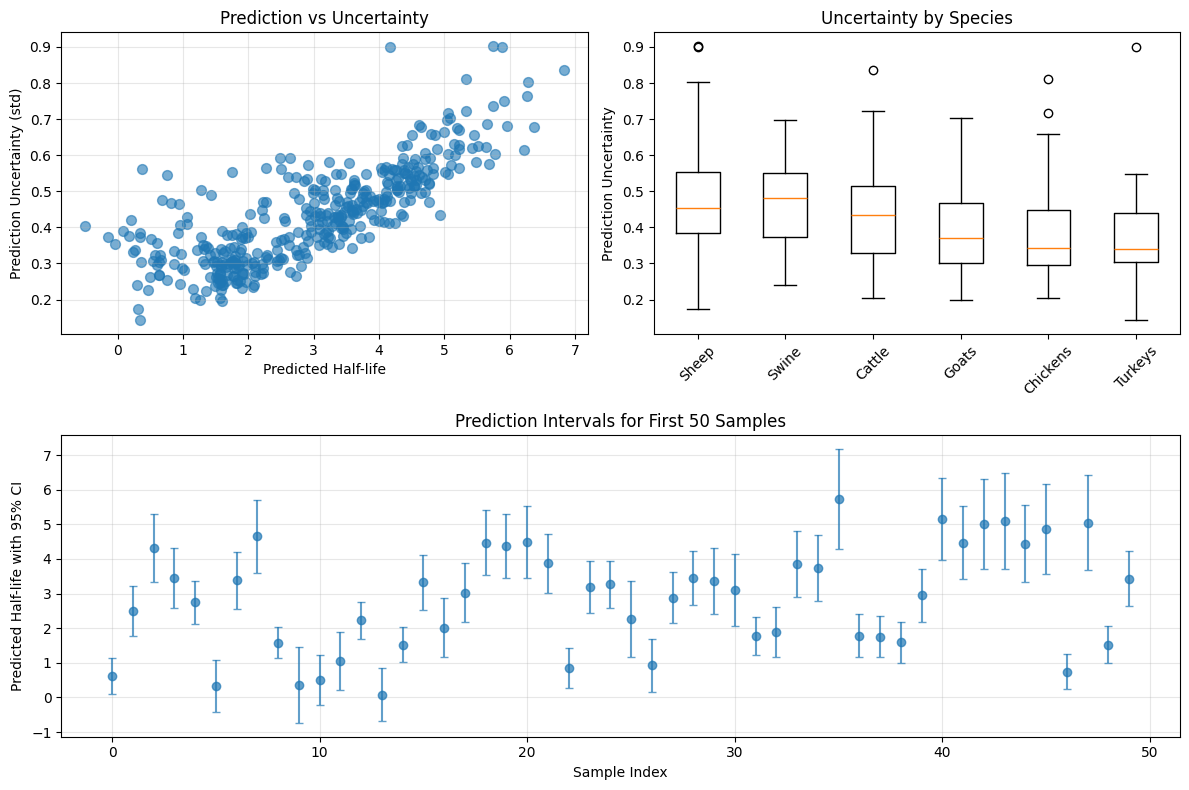


Uncertainty Summary:
Mean prediction uncertainty: 0.4326
Median prediction uncertainty: 0.4271
Range of uncertainties: [0.1421, 0.9026]


In [39]:
def complete_uncertainty_analysis(model, test_loader, device, y_true=None, species_list=None):
    """
    Complete uncertainty quantification pipeline
    """
    print("Starting Comprehensive Uncertainty Analysis...")

    # 1. Monte Carlo Dropout
    print("1. Performing Monte Carlo Dropout...")
    preds_mean, preds_std, all_preds, species_ids = mc_dropout_predictions(
        model, test_loader, device, n_iter=100
    )

    # 2. Calculate prediction intervals
    print("2. Calculating prediction intervals...")
    lower_95, upper_95 = calculate_prediction_intervals(preds_mean, preds_std, confidence=0.95)

    # 3. Create results dataframe
    uncertainty_results = pd.DataFrame({
        'prediction_mean': preds_mean,
        'prediction_std': preds_std,
        'lower_95': lower_95,
        'upper_95': upper_95,
        'species_id': species_ids
    })

    # 4. Species-specific analysis
    if species_list:
        print("3. Analyzing uncertainty by species...")
        species_uncertainty = analyze_uncertainty_by_species(uncertainty_results, species_list)

    # 5. Calibration analysis (if true values available)
    if y_true is not None:
        print("4. Analyzing prediction calibration...")
        calibration_results = analyze_prediction_calibration(y_true, preds_mean, preds_std)

    # 6. Visualizations
    print("5. Creating visualizations...")
    if species_list:
        visualize_uncertainty_analysis(uncertainty_results, species_list)

    # 7. Summary statistics
    print("\nUncertainty Summary:")
    print(f"Mean prediction uncertainty: {np.mean(preds_std):.4f}")
    print(f"Median prediction uncertainty: {np.median(preds_std):.4f}")
    print(f"Range of uncertainties: [{np.min(preds_std):.4f}, {np.max(preds_std):.4f}]")

    return uncertainty_results

# Run complete analysis
uncertainty_results = complete_uncertainty_analysis(
    model, test_loader, device, species_list=species_list
)


APPLICABILITY DOMAIN ANALYSIS

⚠️  IMPORTANT: Using ORIGINAL (non-augmented) training data for AD analysis
This ensures scientifically valid leverage and coverage calculations.

Creating dataloaders with original data...
Original training samples: 1816
Test samples: 401
Augmentation was used for training, but NOT for AD analysis ✓

Extracting latent features from original data...
Train features: (1816, 128)
Test features: (401, 128)

Leverage Statistics:
  Features (p): 128
  Training samples (n): 1816
  Warning threshold (h*): 0.2115
  Train outliers: 37 (2.04%)
  Test outliers: 12 (2.99%)

  Test/Train ratio: 22.08%
  ✓ Reasonable test set size (10-25% of training)

kNN Coverage:
  95% radius (t_knn): 2.1594
  Train in-domain: 95.0%
  Test in-domain: 96.5%
  ✓ Excellent coverage - test set well within training distribution

[Generating Figure 3A - Test Set Leverage]


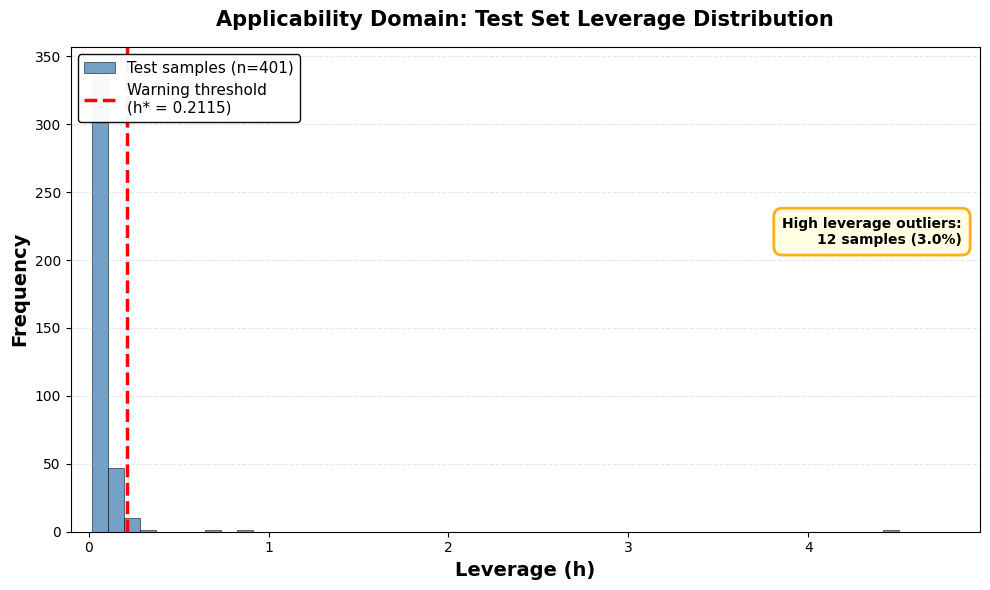

✅ Figure 3A saved (Test Set Only)

[Generating Supplementary Figure - Train Set Leverage]


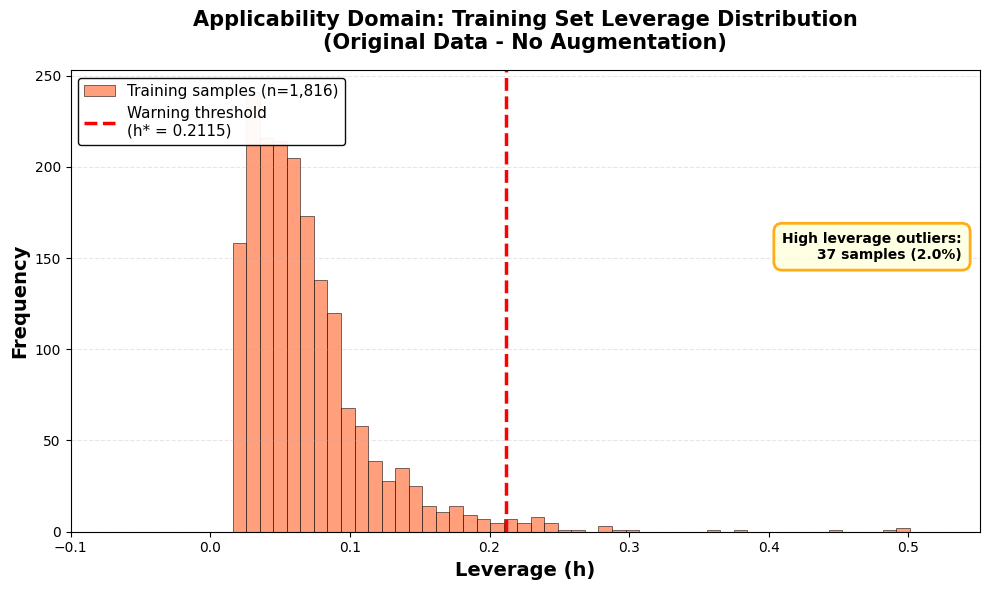

✅ Supplementary figure saved (Train Set)

[Generating Supplementary Figure - Williams Plot]


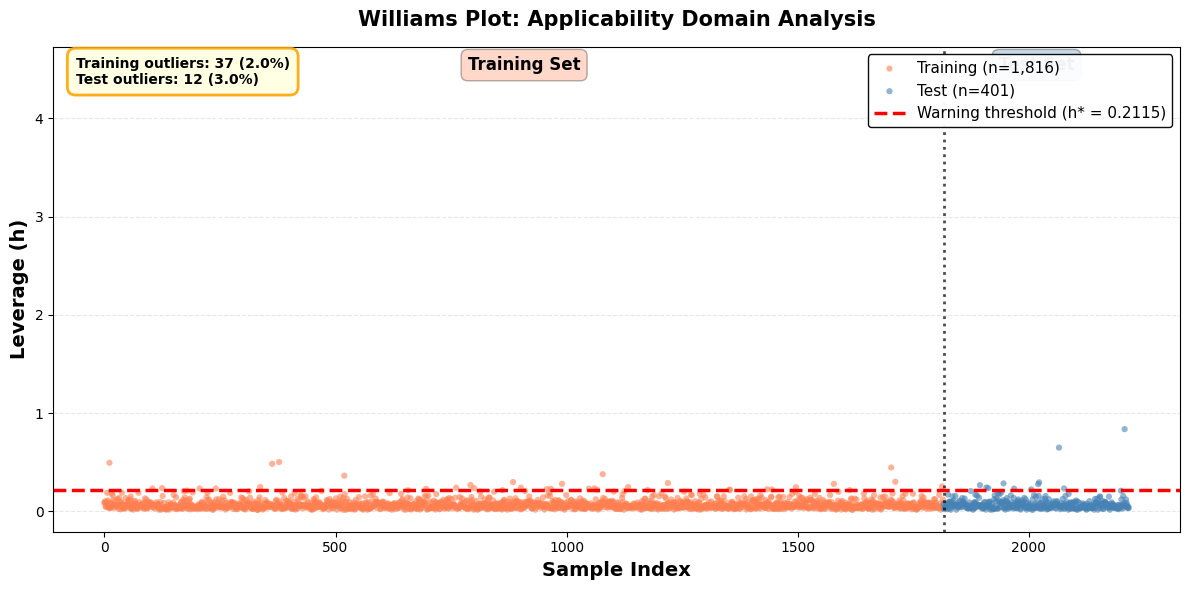

✅ Williams plot saved (Combined Train+Test)

APPLICABILITY DOMAIN ANALYSIS SUMMARY

Dataset Sizes:
  Training (original): 1,816 samples
  Test: 401 samples
  Test/Train ratio: 22.08%

Leverage Analysis:
  Warning threshold (h*): 0.2115
  Train: 37 outliers (2.04%)
  Test:  12 outliers (2.99%)

kNN Coverage:
  Train: 95.0% within 95% radius
  Test:  96.5% within 95% radius

Interpretation:
  ✅ Excellent: Test set predictions within applicability domain


In [40]:
# ============================================================================
# APPLICABILITY DOMAIN ANALYSIS
# ============================================================================

print("="*80)
print("APPLICABILITY DOMAIN ANALYSIS")
print("="*80)
print("\n⚠️  IMPORTANT: Using ORIGINAL (non-augmented) training data for AD analysis")
print("This ensures scientifically valid leverage and coverage calculations.\n")

# ============================================================================
# CREATE LOADERS FOR ORIGINAL (NON-AUGMENTED) DATA
# ============================================================================

# Use the ORIGINAL train_df (not augmented)
print("Creating dataloaders with original data...")
original_train_dataset = HybridMultiTaskDataset(train_df, tokenizer)  # NOT train_aug!
original_test_dataset = HybridMultiTaskDataset(test_df, tokenizer)

# Use larger batch size for faster feature extraction
original_train_loader = DataLoader(original_train_dataset, batch_size=64, shuffle=False)
original_test_loader = DataLoader(original_test_dataset, batch_size=64, shuffle=False)

print(f"Original training samples: {len(train_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Augmentation was used for training, but NOT for AD analysis ✓\n")

# ============================================================================
# EXTRACT FEATURES FROM ORIGINAL DATA
# ============================================================================

print("Extracting latent features from original data...")
X_tr = trunk_features(model, original_train_loader, device, tokenizer)
X_te = trunk_features(model, original_test_loader, device, tokenizer)

if X_tr is None or X_te is None:
    print("AD skipped: could not extract trunk features.")
else:
    print(f"Train features: {X_tr.shape}")
    print(f"Test features: {X_te.shape}")

    # Verify reasonable sizes
    if X_tr.shape[0] > 10000:
        print("\n⚠️  WARNING: Training set has >10K samples. This might include augmented data!")
        print("   Please verify you're using original train_df, not train_aug")

    # ========================================================================
    # CALCULATE LEVERAGE
    # ========================================================================

    # Leverage threshold (based on training set)
    p = X_tr.shape[1]  # Number of features
    n = X_tr.shape[0]  # Number of training samples

    # Hat matrix calculation
    XtX = X_tr.T @ X_tr
    XtX_reg = XtX + 1e-3 * np.eye(p)  # Regularization for stability
    XtX_inv = np.linalg.pinv(XtX_reg)

    def leverage(X):
        """Calculate leverage (diagonal of hat matrix)"""
        return np.sum(X * (X @ XtX_inv), axis=1)

    h_tr = leverage(X_tr)
    h_te = leverage(X_te)
    h_star = 3 * p / max(1, n)  # Warning threshold

    # Calculate outliers
    n_outliers_tr = np.sum(h_tr > h_star)
    n_outliers_te = np.sum(h_te > h_star)

    print(f"\nLeverage Statistics:")
    print(f"  Features (p): {p}")
    print(f"  Training samples (n): {n}")
    print(f"  Warning threshold (h*): {h_star:.4f}")
    print(f"  Train outliers: {n_outliers_tr} ({100*n_outliers_tr/len(h_tr):.2f}%)")
    print(f"  Test outliers: {n_outliers_te} ({100*n_outliers_te/len(h_te):.2f}%)")

    # Interpretation based on sample size ratio
    test_train_ratio = len(h_te) / len(h_tr)
    print(f"\n  Test/Train ratio: {test_train_ratio:.2%}")
    if 0.10 < test_train_ratio < 0.25:
        print("  ✓ Reasonable test set size (10-25% of training)")
    elif test_train_ratio < 0.10:
        print("  ⚠️  Small test set (<10% of training) - consider increasing")
    else:
        print("  ⚠️  Large test set (>25% of training) - consider more training data")

    # ========================================================================
    # kNN COVERAGE
    # ========================================================================

    nbrs = NearestNeighbors(n_neighbors=min(5, len(X_tr))).fit(X_tr)
    dist_tr, _ = nbrs.kneighbors(X_tr)
    dist_te, _ = nbrs.kneighbors(X_te)
    t_knn = float(np.quantile(dist_tr[:, -1], 0.95))
    cov_tr = float(np.mean(dist_tr[:, -1] <= t_knn)) * 100.0
    cov_te = float(np.mean(dist_te[:, -1] <= t_knn)) * 100.0

    print(f"\nkNN Coverage:")
    print(f"  95% radius (t_knn): {t_knn:.4f}")
    print(f"  Train in-domain: {cov_tr:.1f}%")
    print(f"  Test in-domain: {cov_te:.1f}%")

    # Interpretation
    if cov_te > 90:
        print("  ✓ Excellent coverage - test set well within training distribution")
    elif cov_te > 75:
        print("  ✓ Good coverage - most test samples similar to training")
    elif cov_te > 60:
        print("  ⚠️  Moderate coverage - some test samples may be extrapolation")
    else:
        print("  ⚠️  Poor coverage - test set different from training distribution")

    # ========================================================================
    # PLOT 1: TEST SET LEVERAGE - FOR MAIN MANUSCRIPT (Figure 3A)
    # ========================================================================

    print("\n[Generating Figure 3A - Test Set Leverage]")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Histogram of test leverage
    counts, bins, patches = ax.hist(h_te, bins=50, alpha=0.75,
                                     color='steelblue', edgecolor='black', linewidth=0.5,
                                     label=f'Test samples (n={len(h_te):,})')

    # Warning threshold line
    ax.axvline(h_star, color='red', linestyle='--', linewidth=2.5,
               label=f'Warning threshold\n(h* = {h_star:.4f})')

    # Formatting
    ax.set_xlabel('Leverage (h)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax.set_title('Applicability Domain: Test Set Leverage Distribution',
                 fontsize=15, fontweight='bold', pad=15)
    ax.legend(fontsize=11, loc='upper left', framealpha=0.95,
              edgecolor='black', fancybox=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add annotation for outliers only
    outlier_pct = 100*n_outliers_te/len(h_te)
    ax.text(0.98, 0.65, f'High leverage outliers:\n{n_outliers_te:,} samples ({outlier_pct:.1f}%)',
            transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow',
                      alpha=0.9, edgecolor='orange', linewidth=2),
            fontsize=10, fontweight='bold')

    # Set appropriate x-axis limits to show data clearly
    ax.set_xlim(left=-0.1, right=max(h_te.max(), h_star) * 1.1)

    plt.tight_layout()
    plt.savefig('Figure_3A_Test_Leverage.tif', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('Figure_3A_Test_Leverage.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

    print("✅ Figure 3A saved (Test Set Only)")

    # ========================================================================
    # PLOT 2: TRAIN SET LEVERAGE - FOR SUPPLEMENTARY
    # ========================================================================

    print("\n[Generating Supplementary Figure - Train Set Leverage]")

    fig, ax = plt.subplots(figsize=(10, 6))

    # Histogram of train leverage
    counts, bins, patches = ax.hist(h_tr, bins=50, alpha=0.75,
                                     color='coral', edgecolor='black', linewidth=0.5,
                                     label=f'Training samples (n={len(h_tr):,})')

    # Warning threshold line
    ax.axvline(h_star, color='red', linestyle='--', linewidth=2.5,
               label=f'Warning threshold\n(h* = {h_star:.4f})')

    # Formatting
    ax.set_xlabel('Leverage (h)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=14, fontweight='bold')
    ax.set_title('Applicability Domain: Training Set Leverage Distribution\n(Original Data - No Augmentation)',
                 fontsize=15, fontweight='bold', pad=15)
    ax.legend(fontsize=11, loc='upper left', framealpha=0.95,
              edgecolor='black', fancybox=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add annotation for outliers only
    outlier_pct = 100*n_outliers_tr/len(h_tr)
    ax.text(0.98, 0.65, f'High leverage outliers:\n{n_outliers_tr:,} samples ({outlier_pct:.1f}%)',
            transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow',
                      alpha=0.9, edgecolor='orange', linewidth=2),
            fontsize=10, fontweight='bold')

    # Set appropriate x-axis limits
    ax.set_xlim(left=-0.1, right=max(h_tr.max(), h_star) * 1.1)

    plt.tight_layout()
    plt.savefig('Supplementary_Train_Leverage.tif', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('Supplementary_Train_Leverage.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

    print("✅ Supplementary figure saved (Train Set)")

    # ========================================================================
    # PLOT 3: COMBINED WILLIAMS PLOT - FOR SUPPLEMENTARY
    # ========================================================================

    print("\n[Generating Supplementary Figure - Williams Plot]")

    fig, ax = plt.subplots(figsize=(12, 6))

    # Plot train samples
    ax.scatter(np.arange(len(h_tr)), h_tr, s=20, alpha=0.6,
               color='coral', label=f'Training (n={len(h_tr):,})', edgecolors='none')

    # Plot test samples (offset by train length)
    ax.scatter(np.arange(len(h_tr), len(h_tr)+len(h_te)), h_te, s=20, alpha=0.6,
               color='steelblue', label=f'Test (n={len(h_te):,})', edgecolors='none')

    # Warning threshold line
    ax.axhline(h_star, color='red', linestyle='--', linewidth=2.5,
               label=f'Warning threshold (h* = {h_star:.4f})')

    # Add vertical line separating train/test
    ax.axvline(len(h_tr), color='black', linestyle=':', linewidth=2, alpha=0.7)

    # Add region labels
    ax.text(len(h_tr)/2, ax.get_ylim()[1]*0.98, 'Training Set',
            fontsize=12, fontweight='bold', ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='coral', alpha=0.3))
    ax.text(len(h_tr) + len(h_te)/2, ax.get_ylim()[1]*0.98, 'Test Set',
            fontsize=12, fontweight='bold', ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='steelblue', alpha=0.3))

    # Formatting
    ax.set_xlabel('Sample Index', fontsize=14, fontweight='bold')
    ax.set_ylabel('Leverage (h)', fontsize=14, fontweight='bold')
    ax.set_title('Williams Plot: Applicability Domain Analysis',
                 fontsize=15, fontweight='bold', pad=15)
    ax.legend(fontsize=11, loc='upper right', framealpha=0.95,
              edgecolor='black', fancybox=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Add outlier summary annotation
    annotation_text = (
        f'Training outliers: {n_outliers_tr:,} ({100*n_outliers_tr/len(h_tr):.1f}%)\n'
        f'Test outliers: {n_outliers_te:,} ({100*n_outliers_te/len(h_te):.1f}%)'
    )
    ax.text(0.02, 0.98, annotation_text,
            transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='left',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow',
                      alpha=0.9, edgecolor='orange', linewidth=2),
            fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig('Supplementary_Williams_Plot.tif', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.savefig('Supplementary_Williams_Plot.png', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()

    print("✅ Williams plot saved (Combined Train+Test)")

    # ========================================================================
    # SUMMARY STATISTICS
    # ========================================================================

    print("\n" + "="*70)
    print("APPLICABILITY DOMAIN ANALYSIS SUMMARY")
    print("="*70)
    print(f"\nDataset Sizes:")
    print(f"  Training (original): {len(h_tr):,} samples")
    print(f"  Test: {len(h_te):,} samples")
    print(f"  Test/Train ratio: {test_train_ratio:.2%}")

    print(f"\nLeverage Analysis:")
    print(f"  Warning threshold (h*): {h_star:.4f}")
    print(f"  Train: {n_outliers_tr:,} outliers ({100*n_outliers_tr/len(h_tr):.2f}%)")
    print(f"  Test:  {n_outliers_te:,} outliers ({100*n_outliers_te/len(h_te):.2f}%)")

    print(f"\nkNN Coverage:")
    print(f"  Train: {cov_tr:.1f}% within 95% radius")
    print(f"  Test:  {cov_te:.1f}% within 95% radius")

    print(f"\nInterpretation:")
    if n_outliers_te / len(h_te) < 0.05 and cov_te > 90:
        print("  ✅ Excellent: Test set predictions within applicability domain")
    elif n_outliers_te / len(h_te) < 0.10 and cov_te > 75:
        print("  ✅ Good: Most test predictions within applicability domain")
    elif n_outliers_te / len(h_te) < 0.15:
        print("  ⚠️  Moderate: Some test predictions may be extrapolation")
    else:
        print("  ⚠️  Caution: Significant test set outside applicability domain")
        print("     Consider: 1) Collect more training data")
        print("               2) Apply ensemble methods for uncertainty estimation")
        print("               3) Flag predictions with high leverage as uncertain")

    print("="*70)


[Generating Supplementary Figure - Williams Plot]


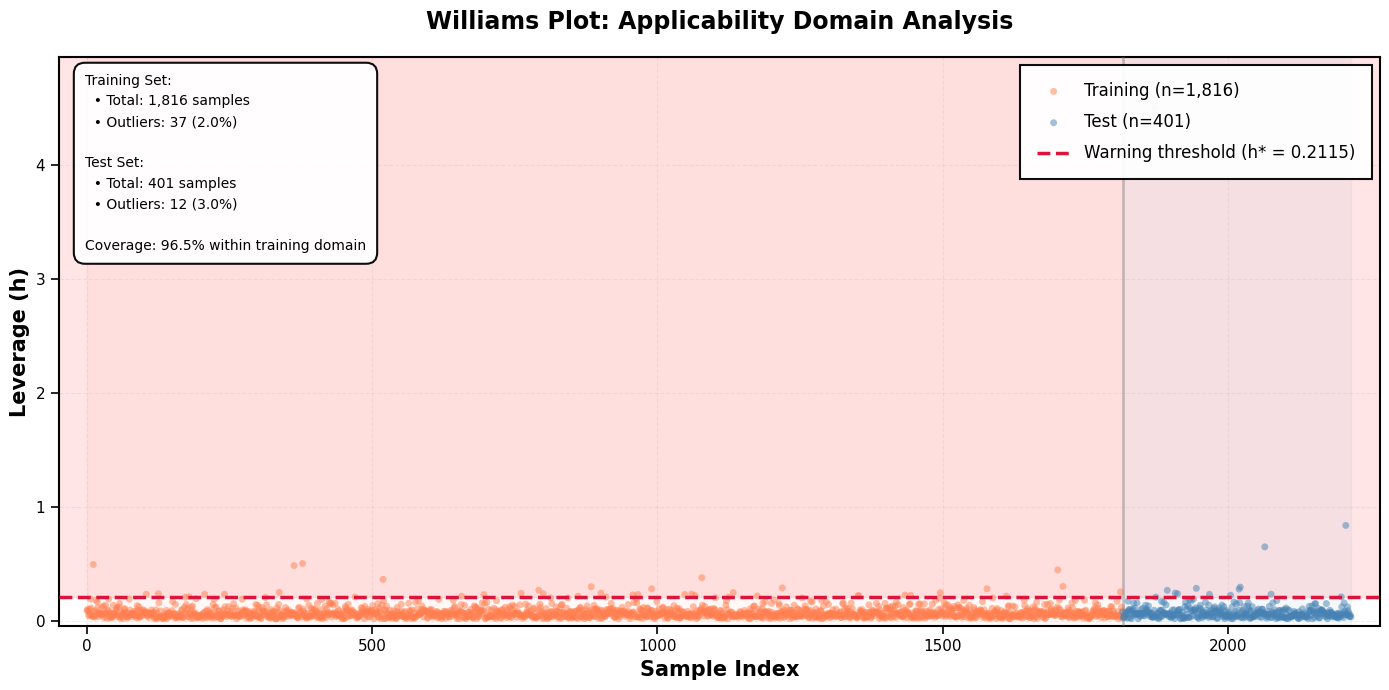

✅ Williams plot saved (Combined Train+Test)


In [41]:
# ========================================================================
# PLOT 3: WILLIAMS PLOT - WITH OPTIMIZED Y-AXIS
# ========================================================================

print("\n[Generating Supplementary Figure - Williams Plot]")

fig, ax = plt.subplots(figsize=(14, 7))

# Plot train samples
ax.scatter(np.arange(len(h_tr)), h_tr, s=25, alpha=0.5,
           color='#FF7F50', label=f'Training (n={len(h_tr):,})',
           edgecolors='none', rasterized=True)

# Plot test samples
ax.scatter(np.arange(len(h_tr), len(h_tr)+len(h_te)), h_te, s=25, alpha=0.5,
           color='#4682B4', label=f'Test (n={len(h_te):,})',
           edgecolors='none', rasterized=True)

# Warning threshold line
ax.axhline(h_star, color='#DC143C', linestyle='--', linewidth=2.5,
           label=f'Warning threshold (h* = {h_star:.4f})', zorder=10)

# Calculate smart y-limit (show all data with minimal white space)
all_leverages = np.concatenate([h_tr, h_te])
y_max_data = all_leverages.max()
y_95 = np.percentile(all_leverages, 95)

# Use 95th percentile * 1.5, but ensure we show the max
y_max = max(y_95 * 1.5, y_max_data * 1.1, h_star * 2)  # At least 2x threshold
ax.set_ylim(-0.05, y_max)

# Add shaded region only up to actual y_max (not beyond)
ax.axhspan(h_star, y_max, alpha=0.1, color='red', zorder=0)

# Add vertical separator with shading
ax.axvline(len(h_tr), color='gray', linestyle='-', linewidth=2, alpha=0.4, zorder=5)
ax.axvspan(0, len(h_tr), alpha=0.05, color='coral', zorder=0)
ax.axvspan(len(h_tr), len(h_tr)+len(h_te), alpha=0.05, color='steelblue', zorder=0)

# Formatting
ax.set_xlabel('Sample Index', fontsize=15, fontweight='bold')
ax.set_ylabel('Leverage (h)', fontsize=15, fontweight='bold')
ax.set_title('Williams Plot: Applicability Domain Analysis',
             fontsize=17, fontweight='bold', pad=20)

# Professional legend
legend = ax.legend(fontsize=12, loc='upper right', framealpha=0.95,
                   edgecolor='black', fancybox=False, frameon=True,
                   borderpad=1, labelspacing=0.8)
legend.get_frame().set_linewidth(1.5)

# Grid
ax.grid(axis='both', alpha=0.2, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Statistics box
stats_text = (
    f'Training Set:\n'
    f'  • Total: {len(h_tr):,} samples\n'
    f'  • Outliers: {n_outliers_tr} ({100*n_outliers_tr/len(h_tr):.1f}%)\n\n'
    f'Test Set:\n'
    f'  • Total: {len(h_te):,} samples\n'
    f'  • Outliers: {n_outliers_te} ({100*n_outliers_te/len(h_te):.1f}%)\n\n'
    f'Coverage: {cov_te:.1f}% within training domain'
)

ax.text(0.02, 0.97, stats_text,
        transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white',
                  edgecolor='black', linewidth=1.5, alpha=0.95),
        fontsize=10, linespacing=1.6, family='sans-serif')

# Set x-axis limit with padding
ax.set_xlim(-50, len(h_tr) + len(h_te) + 50)

# Improve tick appearance
ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)

# Add subtle border
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.savefig('Supplementary_Williams_Plot.tif', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.savefig('Supplementary_Williams_Plot.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Williams plot saved (Combined Train+Test)")